# 14 — $P\times M$ 多 stream 并行 QOS ensemble 真机实验

这本 notebook 在一条宽 OpenQASM 线路中打包 $P$ 个相互独立的
二比特 IMDb-QOS echo 子线路，并同时扫描

$$
P\in\{1,2,4,8,16\},
\qquad
M\in\{4,8,16,32,64,96\}.
$$

对每个选定的 $P$，notebook 会生成六条宽线路，每个 $M$ 对应：

- **一个宽 QASM**；
- **一个 Quafu task ID**；
- **一份独立 manifest、raw result 与 returned-QASM 审计**。

因此一次 `submit` 的 `Run All` 会顺序创建六个 task，一次 `fetch`
会逐个检查并取回这六个 task。五个 $P$ 全部完成后总计 30 个
task ID。这里的“批量”不是平台原子事务；若中途失败，已经返回的
task ID 会立即落盘，之后只能显式补交缺失的 $M$。

一次硬件 shot 会同时返回 $P$ 对二比特结果。Notebook 对完整
$2P$-bit 联合 counts 做逐 pair 边缘化，而不是错误地使用
$P(0^{2P})$。

这项实验研究空间并发、数据流长度、同-shot 共享噪声和编译布局的
联合响应面。它不能单独证明量子优势，也不能把所有退化都归因于串扰。


In [176]:
# =========================
# 用户通常只需要修改这个配置单元
# =========================

# 可选：dry_run | status | submit | retry | fetch
ACTION = "fetch"

# 每轮只选一个 P；该轮自动处理全部六个 M。
P_VALUES = (1, 2, 4, 8, 16)
M_VALUES = (4, 8, 16, 32, 64, 96)
P_SELECTED = 4
PREVIEW_M = 8
SHOTS = 4096

# 先为每个 pair 生成长度 96 的母 stream，再取前 M 个样本。
# 因此 P 与 M 两个方向都是嵌套、可匹配比较的设计。
BASE_STREAM_SEED = 20260731
REPLICATE_ID = 0
ASSIGNMENT_ID = "auto_v0"

BACKEND = "Shenglian"
COMPILER = "qsteed"
USE_READOUT_CORRECTION = False
OPEN_DD = None                 # None | "XY4" | "CPMG"
BACKEND_QUBITS = 84

# target_qubits 只是编译器可使用的物理集合，不保证列表顺序就是
# logical -> physical 映射。真正映射会从 returned QASM 恢复。
TARGET_QUBITS_BY_P = {
    1: [34, 40],
    2: [],
    4: [],
    8: [],
    16: [],
}

# 使用新 campaign，避免与旧的固定 M=8 pilot 混合。
CAMPAIGN_LABEL = "imdb_parallel_qos_grid_001"
DESIGN_ID = "pm_grid_v1"
SCHEMA_VERSION = 2

# 真机提交安全门。dry_run 会显示当前批次 digest 和正确确认词。
CONFIRM_REAL_SUBMISSION = ""
CONFIRM_BATCH_DIGEST = ""
MAX_TASKS_PER_SUBMISSION = 6

# 若一次六任务提交中途失败，默认不盲目重试。核实 registry 后，
# 显式开启此项，只补交缺失 M。
RESUME_PARTIAL_BATCH = False
ALLOW_DUPLICATE_SUBMISSION = False

# 仅用于处理 submission_intent="ambiguous"：
# - 若平台上确有对应任务，填入 {M: task_id}；
# - 若已确认平台根本没有创建任务，把 M 放进第二个 tuple。
# 两种恢复都还需要 RESUME_PARTIAL_BATCH、resume 确认词和 batch digest。
RECOVER_TASK_IDS_BY_M = {}
AMBIGUOUS_M_VERIFIED_NOT_SUBMITTED = ()

# 已有 task ID、但平台终态失败或 returned-layout 审计失败时，
# 使用 ACTION="retry" 只替换明确列出的 M。默认必须为空。
RETRY_M_VALUES = ()
MAX_TASKS_PER_RETRY = 6

# retry API 若在返回 task ID 前连接中断，也必须先到平台按 task_name
# 核实；平台确有任务时填第一项，确认未创建时填第二项。
RECOVER_RETRY_TASK_IDS_BY_M = {}
RETRY_M_VERIFIED_NOT_SUBMITTED = ()

# 默认要求上一个 P 的六个 M 均成功 fetch 且 returned-layout 审计通过。
REQUIRE_PREVIOUS_P_SUCCESS = True
ALLOW_SKIP_LADDER = False

RESULT_TIMEOUT_SECONDS = 60
FORCE_FETCH_NONFINISHED = False
REFETCH_COMPLETED = False


## 1. 二维嵌套设计与统计量

第 $r$ 个 pair 先固定生成长度 96 的母 stream，较短数据流只取前缀：

$$
s_{r,M}=s_{r,96}[0:M].
$$

同时，$P=8$ 的前四条 stream 与 $P=4$ 完全相同。这样沿 $M$
方向只是延长同一条数据流，沿 $P$ 方向只是增加新的独立 stream。

第 $s$ 个硬件 shot、pair $r$ 的成功事件定义为

$$
X_{sr}
=
\mathbf 1\{c_{2r}=0,\ c_{2r+1}=0\}.
$$

单 pair echo fidelity 与 ensemble mean 是

$$
\widehat F_r=\frac1S\sum_{s=1}^{S}X_{sr},
\qquad
\widehat\mu_{P,M}=\frac1P\sum_{r=0}^{P-1}\widehat F_r.
$$

为保留同一个硬件 shot 中不同 pair 的相关性，令

$$
Z_s=\frac1P\sum_r X_{sr},
\qquad
\widehat{\rm SE}_{\rm cluster}
=
\sqrt{\frac{\widehat{\rm Var}(Z_s)}{S}}.
$$

每个网格点比较三种量：

1. 真机 $\widehat\mu_{\rm hw}(P,M)$；
2. 完全相同固定 streams 的无噪声 $\mu_{\rm fixed}(P,M)$；
3. 对随机 streams 再取期望的解析 $\mathbb E_{\rm IID}[F(M)]$。

硬件损失定义为

$$
\Delta(P,M)
=
\mu_{\rm fixed}(P,M)-\widehat\mu_{\rm hw}(P,M).
$$

有效并行度使用

$$
P_{\rm eff}
=
\frac{\frac1P\sum_r{\rm Var}(X_r)}
     {{\rm Var}(Z)}.
$$

Notebook 同时保留未截断的 $P_{\rm eff}$、$P_{\rm eff}/P$、设计效应、
有符号/绝对 pair 相关性。它们是“串扰感知或共享噪声指标”，不是
已经分离出的因果串扰参数。


In [177]:
import hashlib
import json
import math
import os
import platform
import re
from datetime import datetime, timezone
from getpass import getpass
from importlib.metadata import version
from pathlib import Path
from uuid import uuid4

os.environ.setdefault(
    "MPLCONFIGDIR", "/private/tmp/parallel-qos-mplconfig"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from qiskit import qasm2
from qiskit.circuit import Gate
from qiskit.quantum_info import Statevector


def resolve_project_root():
    configured = os.getenv("QUAFU_PROJECT_ROOT", "").strip()
    candidates = []
    if configured:
        candidates.append(Path(configured))
    candidates.extend((Path.cwd(), Path.cwd().parent))
    for candidate in candidates:
        target = (
            candidate
            / "results/imdb_vector_pilot/imdb_d4_target.json"
        )
        if target.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "找不到 Quafu 项目根目录或 IMDb target。"
        "请从项目根目录或 notebooks/ 启动，并先运行 Notebook 09。"
    )


PROJECT_ROOT = resolve_project_root()
TARGET_PATH = (
    PROJECT_ROOT
    / "results/imdb_vector_pilot/imdb_d4_target.json"
)
RESULT_ROOT = PROJECT_ROOT / "results/qos_parallel_ensemble"
QASM_DIR = RESULT_ROOT / "qasm"
MANIFEST_DIR = RESULT_ROOT / "manifests"
BATCH_DIR = RESULT_ROOT / "batch_manifests"
AUDIT_DIR = RESULT_ROOT / "offline_audits"
RAW_RESULT_DIR = RESULT_ROOT / "raw_results"
INTENT_DIR = RESULT_ROOT / "submission_intents"
REGISTRY_PATH = RESULT_ROOT / "task_registry.json"
TASK_RESULTS_JSON = RESULT_ROOT / "hardware_tasks.json"
TASK_RESULTS_CSV = RESULT_ROOT / "hardware_tasks.csv"
PAIR_RESULTS_JSON = RESULT_ROOT / "hardware_pairs.json"
PAIR_RESULTS_CSV = RESULT_ROOT / "hardware_pairs.csv"
FETCH_ATTEMPTS_JSON = RESULT_ROOT / "fetch_attempts.json"

for directory in (
    RESULT_ROOT,
    QASM_DIR,
    MANIFEST_DIR,
    BATCH_DIR,
    AUDIT_DIR,
    RAW_RESULT_DIR,
    INTENT_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

if ACTION not in {"dry_run", "status", "submit", "retry", "fetch"}:
    raise ValueError(f"Unknown ACTION: {ACTION!r}")
if tuple(P_VALUES) != (1, 2, 4, 8, 16):
    raise ValueError("This design is frozen to P=(1,2,4,8,16).")
if tuple(M_VALUES) != (4, 8, 16, 32, 64, 96):
    raise ValueError(
        "This design is frozen to M=(4,8,16,32,64,96)."
    )
if len(set(P_VALUES)) != len(P_VALUES):
    raise ValueError("P_VALUES must be unique.")
if len(set(M_VALUES)) != len(M_VALUES):
    raise ValueError("M_VALUES must be unique.")
if P_SELECTED not in P_VALUES:
    raise ValueError(f"P_SELECTED must be one of {P_VALUES}.")
if PREVIEW_M not in M_VALUES:
    raise ValueError(f"PREVIEW_M must be one of {M_VALUES}.")
if SHOTS <= 0 or SHOTS % 1024 != 0:
    raise ValueError("SHOTS must be a positive multiple of 1024.")
if 2 * P_SELECTED > BACKEND_QUBITS:
    raise ValueError("Selected P exceeds configured backend width.")
if COMPILER not in {None, "quarkcircuit", "qsteed", "qiskit"}:
    raise ValueError(f"Unsupported compiler: {COMPILER!r}")
if OPEN_DD not in {None, "XY4", "CPMG"}:
    raise ValueError("OPEN_DD must be None, 'XY4', or 'CPMG'.")
if USE_READOUT_CORRECTION:
    raise ValueError(
        "This joint-count design requires "
        "USE_READOUT_CORRECTION=False."
    )
if not re.fullmatch(r"[A-Za-z0-9_-]+", CAMPAIGN_LABEL):
    raise ValueError("CAMPAIGN_LABEL contains unsafe characters.")
if not re.fullmatch(r"[A-Za-z0-9_-]+", DESIGN_ID):
    raise ValueError("DESIGN_ID contains unsafe characters.")
if not re.fullmatch(r"[A-Za-z0-9_-]+", ASSIGNMENT_ID):
    raise ValueError("ASSIGNMENT_ID contains unsafe characters.")
if MAX_TASKS_PER_SUBMISSION != len(M_VALUES):
    raise ValueError(
        "MAX_TASKS_PER_SUBMISSION must equal the six-M batch size."
    )
if ALLOW_DUPLICATE_SUBMISSION:
    raise ValueError(
        "ALLOW_DUPLICATE_SUBMISSION must remain False; "
        "use RESUME_PARTIAL_BATCH for missing cells."
    )
recovery_m = {int(key) for key in RECOVER_TASK_IDS_BY_M}
verified_missing_m = {
    int(item)
    for item in AMBIGUOUS_M_VERIFIED_NOT_SUBMITTED
}
if not recovery_m.issubset(set(M_VALUES)):
    raise ValueError(
        "RECOVER_TASK_IDS_BY_M contains an unsupported M."
    )
if not verified_missing_m.issubset(set(M_VALUES)):
    raise ValueError(
        "AMBIGUOUS_M_VERIFIED_NOT_SUBMITTED contains "
        "an unsupported M."
    )
if recovery_m & verified_missing_m:
    raise ValueError(
        "One ambiguous M cannot be both recovered and "
        "verified not submitted."
    )
for recovered_task_id in RECOVER_TASK_IDS_BY_M.values():
    if (
        not isinstance(recovered_task_id, int)
        or isinstance(recovered_task_id, bool)
        or recovered_task_id <= 0
    ):
        raise ValueError(
            "RECOVER_TASK_IDS_BY_M values must be positive "
            "integer task IDs."
        )

retry_m_values = tuple(int(item) for item in RETRY_M_VALUES)
if len(retry_m_values) != len(set(retry_m_values)):
    raise ValueError("RETRY_M_VALUES must be unique.")
if not set(retry_m_values).issubset(set(M_VALUES)):
    raise ValueError("RETRY_M_VALUES contains an unsupported M.")
retry_m_values = tuple(sorted(retry_m_values))
if MAX_TASKS_PER_RETRY != len(M_VALUES):
    raise ValueError(
        "MAX_TASKS_PER_RETRY must equal the six-M safety limit."
    )
retry_recovery_m = {
    int(key) for key in RECOVER_RETRY_TASK_IDS_BY_M
}
retry_verified_missing_m = {
    int(item) for item in RETRY_M_VERIFIED_NOT_SUBMITTED
}
if not retry_recovery_m.issubset(set(retry_m_values)):
    raise ValueError(
        "RECOVER_RETRY_TASK_IDS_BY_M must be a subset of "
        "RETRY_M_VALUES."
    )
if not retry_verified_missing_m.issubset(set(retry_m_values)):
    raise ValueError(
        "RETRY_M_VERIFIED_NOT_SUBMITTED must be a subset "
        "of RETRY_M_VALUES."
    )
if retry_recovery_m & retry_verified_missing_m:
    raise ValueError(
        "One retry M cannot be both recovered and verified "
        "not submitted."
    )
for recovered_task_id in RECOVER_RETRY_TASK_IDS_BY_M.values():
    if (
        not isinstance(recovered_task_id, int)
        or isinstance(recovered_task_id, bool)
        or recovered_task_id <= 0
    ):
        raise ValueError(
            "RECOVER_RETRY_TASK_IDS_BY_M values must be "
            "positive integer task IDs."
        )
if ACTION == "retry" and not retry_m_values:
    raise ValueError(
        "ACTION=retry requires non-empty RETRY_M_VALUES."
    )
if ACTION not in {"dry_run", "retry"} and retry_m_values:
    raise ValueError(
        "Clear RETRY_M_VALUES unless ACTION is dry_run or retry."
    )
if ACTION == "retry" and RESUME_PARTIAL_BATCH:
    raise ValueError(
        "Retry and partial-batch resume cannot be enabled together."
    )

target_qubits = [
    int(item)
    for item in TARGET_QUBITS_BY_P.get(P_SELECTED, [])
]
if target_qubits and (
    len(target_qubits) != 2 * P_SELECTED
    or len(set(target_qubits)) != len(target_qubits)
    or min(target_qubits) < 0
    or max(target_qubits) >= BACKEND_QUBITS
):
    raise ValueError(
        "Nonempty TARGET_QUBITS_BY_P[P] must contain exactly "
        "2P distinct physical indices in backend range."
    )

target_payload = json.loads(
    TARGET_PATH.read_text(encoding="utf-8")
)
D = int(target_payload["D"])
SIGNS = np.asarray(
    target_payload["sign_pattern"], dtype=np.int8
)
if D != 4 or SIGNS.tolist() != [1, -1, -1, -1]:
    raise AssertionError(
        "This design is frozen to S_IMDB=(+1,-1,-1,-1)."
    )
N_ADDRESS = int(round(math.log2(D)))
BOOLEAN_F = ((1 - SIGNS) // 2).astype(np.int8)

ENVIRONMENT = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "qiskit": version("qiskit"),
    "quafusqc": version("quafusqc"),
}

print("Project root:", PROJECT_ROOT)
print("Action:", ACTION)
print("Current P:", P_SELECTED)
print("Logical width:", 2 * P_SELECTED)
print("M batch:", M_VALUES)
print("Tasks in this P batch:", len(M_VALUES))
print(
    "Layout request:",
    target_qubits if target_qubits else "qsteed auto",
)
display(pd.Series(ENVIRONMENT, name="version").to_frame())


Project root: /Users/tangzhi/Desktop/Quafu
Action: fetch
Current P: 4
Logical width: 8
M batch: (4, 8, 16, 32, 64, 96)
Tasks in this P batch: 6
Layout request: qsteed auto


,version
python,3.13.7
numpy,2.3.3
pandas,2.3.2
qiskit,2.5.1
quafusqc,3.3.9


## 2. 生成六个 $M$ 的嵌套 streams 与宽 QASM

对固定 replica index $r$，stream seed 不随 $P$ 或 $M$ 改变。
Notebook 先生成长度 96 的母 stream，再对六个 $M$ 取前缀。

每条宽线路采用 sample-step 同步结构：同一个流时间步内，各 pair
的门作用于不相交量子比特；每个 sample step 后才使用全局 barrier。
线路二比特门总数随 $P$ 和 $M$ 增长，但在理想并行映射下，宽度 $P$
本身不应让逻辑二比特深度线性增长。

$P=16$ 是 32 个逻辑比特，禁止构造全宽 statevector。这里只分别验证
每个二比特子线路，并审计每个宽 QASM 不存在跨 logical-pair 的
二比特门。


In [178]:
def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"Cannot encode {type(value).__name__}")


def write_json_atomic(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(
        json.dumps(
            payload,
            indent=2,
            ensure_ascii=False,
            default=json_default,
        ),
        encoding="utf-8",
    )
    temporary.replace(path)


def sha256_text(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def stream_sha256(stream):
    return hashlib.sha256(
        np.asarray(stream, dtype=np.int64).tobytes()
    ).hexdigest()


def seed_for_replica(replica_index):
    sequence = np.random.SeedSequence(
        [BASE_STREAM_SEED, REPLICATE_ID, int(replica_index)]
    )
    return int(sequence.generate_state(1, dtype=np.uint64)[0])


def full_stream_for_replica(replica_index):
    rng = np.random.default_rng(seed_for_replica(replica_index))
    return rng.integers(
        0, D, size=max(M_VALUES), dtype=np.int64
    )


def append_projector_phase(
    lines, q0, q1, address, angle
):
    qubits = (int(q0), int(q1))
    zero_local_bits = [
        bit
        for bit in range(N_ADDRESS)
        if ((int(address) >> bit) & 1) == 0
    ]
    for bit in zero_local_bits:
        lines.append(f"x q[{qubits[bit]}];")
    half_angle = float(angle) / 2
    lines.extend(
        [
            f"u1({half_angle:.16g}) q[{qubits[0]}];",
            f"cx q[{qubits[0]}],q[{qubits[1]}];",
            f"u1({-half_angle:.16g}) q[{qubits[1]}];",
            f"cx q[{qubits[0]}],q[{qubits[1]}];",
            f"u1({half_angle:.16g}) q[{qubits[1]}];",
        ]
    )
    for bit in reversed(zero_local_bits):
        lines.append(f"x q[{qubits[bit]}];")


def build_single_echo_qasm(stream):
    stream = np.asarray(stream, dtype=np.int64)
    theta = np.pi * D / len(stream)
    lines = [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        "qreg q[2];",
        "creg c[2];",
        "h q[0];",
        "h q[1];",
        "barrier q;",
    ]
    for address in stream:
        if BOOLEAN_F[int(address)] == 1:
            append_projector_phase(
                lines, 0, 1, int(address), theta
            )
        lines.append("barrier q;")
    for address, value in enumerate(BOOLEAN_F):
        if int(value) == 1:
            append_projector_phase(
                lines, 0, 1, address, -np.pi
            )
        lines.append("barrier q;")
    lines.extend(
        [
            "h q[0];",
            "h q[1];",
            "barrier q;",
            "measure q[0] -> c[0];",
            "measure q[1] -> c[1];",
        ]
    )
    return "\n".join(lines) + "\n"


def build_packed_echo_qasm(streams):
    streams = [
        np.asarray(stream, dtype=np.int64)
        for stream in streams
    ]
    lengths = {len(stream) for stream in streams}
    if not streams or len(lengths) != 1:
        raise ValueError(
            "Packed streams must be nonempty and equally long."
        )
    m_data = int(next(iter(lengths)))
    if m_data not in M_VALUES:
        raise ValueError(f"Unexpected M={m_data}.")
    p_value = len(streams)
    width = 2 * p_value
    theta = np.pi * D / m_data
    lines = [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        f"qreg q[{width}];",
        f"creg c[{width}];",
    ]
    for qubit in range(width):
        lines.append(f"h q[{qubit}];")
    lines.append("barrier q;")

    for sample_index in range(m_data):
        for replica_index, stream in enumerate(streams):
            address = int(stream[sample_index])
            if BOOLEAN_F[address] == 1:
                append_projector_phase(
                    lines,
                    2 * replica_index,
                    2 * replica_index + 1,
                    address,
                    theta,
                )
        lines.append("barrier q;")

    for address, value in enumerate(BOOLEAN_F):
        if int(value) == 1:
            for replica_index in range(p_value):
                append_projector_phase(
                    lines,
                    2 * replica_index,
                    2 * replica_index + 1,
                    address,
                    -np.pi,
                )
        lines.append("barrier q;")

    for qubit in range(width):
        lines.append(f"h q[{qubit}];")
    lines.append("barrier q;")
    for qubit in range(width):
        lines.append(f"measure q[{qubit}] -> c[{qubit}];")
    return "\n".join(lines) + "\n"


def fixed_stream_metrics(stream):
    stream = np.asarray(stream, dtype=np.int64)
    counts = np.bincount(stream, minlength=D)
    theta = np.pi * D / len(stream)
    sampled_diag = np.exp(
        1j * theta * counts * BOOLEAN_F
    )
    target_diag = np.exp(1j * np.pi * BOOLEAN_F)
    residual = sampled_diag * np.conj(target_diag)
    return {
        "stream_counts": counts.tolist(),
        "fixed_operator_error": float(
            np.max(np.abs(sampled_diag - target_diag))
        ),
        "ideal_F_echo_fixed": float(
            abs(np.mean(residual)) ** 2
        ),
    }


def expected_iid_F_echo(m_data):
    k_negative = int(np.sum(BOOLEAN_F))
    k_positive = D - k_negative
    theta = np.pi * D / m_data
    a = (
        1 - 1 / D + np.exp(1j * theta) / D
    ) ** m_data
    b = (
        1 + 2 * (np.cos(theta) - 1) / D
    ) ** m_data
    return float(
        (
            k_positive**2
            + k_negative
            + k_negative * (k_negative - 1) * b
            - 2
            * k_negative
            * k_positive
            * np.real(a)
        )
        / D**2
    )


def task_fingerprint_payload(record):
    return {
        "schema_version": int(record["schema_version"]),
        "design_id": record["design_id"],
        "campaign_label": record["campaign_label"],
        "experiment_id": record["experiment_id"],
        "qasm_sha256": record["qasm_sha256"],
        "stream_set_sha256": record["stream_set_sha256"],
        "P": int(record["P_parallel_streams"]),
        "M": int(record["M_data_per_stream"]),
        "base_stream_seed": int(record["base_stream_seed"]),
        "replicate_id": int(record["replicate_id"]),
        "assignment_id": record["assignment_id"],
        "shots": int(record["shots"]),
        "backend": record["backend"],
        "compiler": record["compiler"],
        "correct": bool(record["correct"]),
        "open_dd": record["open_dd"],
        "target_qubits": [
            int(item) for item in record["target_qubits"]
        ],
    }


def task_fingerprint_sha256(record):
    canonical = json.dumps(
        task_fingerprint_payload(record),
        sort_keys=True,
        separators=(",", ":"),
    )
    return sha256_text(canonical)


mother_streams = {
    replica_index: full_stream_for_replica(replica_index)
    for replica_index in range(P_SELECTED)
}
experiment_bundles = {}

for m_data in M_VALUES:
    streams = [
        mother_streams[replica_index][:m_data].copy()
        for replica_index in range(P_SELECTED)
    ]
    stream_entries = []
    single_circuits = []
    for replica_index, stream in enumerate(streams):
        seed = seed_for_replica(replica_index)
        metrics = fixed_stream_metrics(stream)
        single_qasm = build_single_echo_qasm(stream)
        single_circuit = qasm2.loads(single_qasm)
        bare = single_circuit.remove_final_measurements(
            inplace=False
        )
        state = np.asarray(
            Statevector.from_instruction(bare).data
        )
        if not np.isclose(
            abs(state[0]) ** 2,
            metrics["ideal_F_echo_fixed"],
            atol=1e-10,
        ):
            raise AssertionError(
                "Statevector mismatch for "
                f"P={P_SELECTED}, M={m_data}, "
                f"replica={replica_index}"
            )
        single_circuits.append(single_circuit)
        single_ops = {
            str(key): int(value)
            for key, value in single_circuit.count_ops().items()
        }
        stream_entries.append(
            {
                "pair_index": int(replica_index),
                "stream_seed": int(seed),
                "stream": stream.tolist(),
                "stream_sha256": stream_sha256(stream),
                "mother_stream_sha256": stream_sha256(
                    mother_streams[replica_index]
                ),
                **metrics,
                "logical_cx": single_ops.get("cx", 0),
                "logical_depth": single_circuit.depth(),
            }
        )

    packed_qasm = build_packed_echo_qasm(streams)
    packed_circuit = qasm2.loads(packed_qasm)
    packed_ops = {
        str(key): int(value)
        for key, value in packed_circuit.count_ops().items()
    }
    logical_two_qubit_gates = []
    logical_cross_pair_gates = []
    for instruction in packed_circuit.data:
        if (
            isinstance(instruction.operation, Gate)
            and instruction.operation.num_qubits == 2
        ):
            indices = tuple(
                packed_circuit.find_bit(qubit).index
                for qubit in instruction.qubits
            )
            logical_two_qubit_gates.append(indices)
            if indices[0] // 2 != indices[1] // 2:
                logical_cross_pair_gates.append(indices)

    expected_cx = sum(
        int(entry["logical_cx"]) for entry in stream_entries
    )
    if packed_ops.get("cx", 0) != expected_cx:
        raise AssertionError(
            f"Packed CX count is not additive for M={m_data}."
        )
    if logical_cross_pair_gates:
        raise AssertionError(
            "Cross-pair logical gates found for "
            f"M={m_data}: {logical_cross_pair_gates}"
        )
    if packed_circuit.num_qubits != 2 * P_SELECTED:
        raise AssertionError("Packed logical width mismatch.")
    if packed_circuit.num_clbits != 2 * P_SELECTED:
        raise AssertionError("Packed classical width mismatch.")

    stream_set_hash = sha256_text(
        json.dumps(
            [entry["stream_sha256"] for entry in stream_entries],
            separators=(",", ":"),
        )
    )
    grid_cell_id = f"P{P_SELECTED}_M{m_data}"
    experiment_id = (
        f"imdb_parallel_grid_M{m_data}_P{P_SELECTED}_"
        f"seed{BASE_STREAM_SEED}_rep{REPLICATE_ID}_"
        f"{ASSIGNMENT_ID}"
    )
    run_label = (
        f"{CAMPAIGN_LABEL}_M{m_data}_P{P_SELECTED}_"
        f"rep{REPLICATE_ID}"
    )
    qasm_path = QASM_DIR / f"{experiment_id}.qasm"
    qasm_path.write_text(packed_qasm, encoding="utf-8")

    manifest = {
        "schema_version": SCHEMA_VERSION,
        "design_id": DESIGN_ID,
        "experiment_id": experiment_id,
        "grid_cell_id": grid_cell_id,
        "run_label": run_label,
        "family": "imdb_parallel_boolean_qos_pm_grid",
        "campaign_label": CAMPAIGN_LABEL,
        "D": D,
        "n_address_qubits_per_pair": N_ADDRESS,
        "P_parallel_streams": P_SELECTED,
        "logical_width": 2 * P_SELECTED,
        "M_data_per_stream": m_data,
        "total_classical_samples": P_SELECTED * m_data,
        "S_shots": SHOTS,
        "base_stream_seed": BASE_STREAM_SEED,
        "replicate_id": REPLICATE_ID,
        "assignment_id": ASSIGNMENT_ID,
        "stream_mode": "two_axis_nested_independent_iid",
        "stream_prefix_nested_across_M": True,
        "pair_prefix_nested_across_P": True,
        "sign_vector": SIGNS.tolist(),
        "boolean_truth_table": BOOLEAN_F.tolist(),
        "stream_set_sha256": stream_set_hash,
        "streams": stream_entries,
        "ideal_ensemble_mean": float(
            np.mean(
                [
                    entry["ideal_F_echo_fixed"]
                    for entry in stream_entries
                ]
            )
        ),
        "ideal_stream_sd": float(
            np.std(
                [
                    entry["ideal_F_echo_fixed"]
                    for entry in stream_entries
                ],
                ddof=1,
            )
            if P_SELECTED > 1
            else 0.0
        ),
        "analytic_E_iid_F_echo": expected_iid_F_echo(m_data),
        "logical_depth": packed_circuit.depth(),
        "logical_two_qubit_depth": packed_circuit.depth(
            filter_function=lambda item: (
                isinstance(item.operation, Gate)
                and item.operation.num_qubits == 2
            )
        ),
        "logical_two_qubit_gates": len(
            logical_two_qubit_gates
        ),
        "logical_cross_pair_two_qubit_gates": len(
            logical_cross_pair_gates
        ),
        "logical_ops": packed_ops,
        "target_qubits_requested": target_qubits,
        "layout_request_mode": (
            "restricted_physical_set"
            if target_qubits
            else "compiler_auto"
        ),
        "qasm_path": str(qasm_path.relative_to(PROJECT_ROOT)),
        "qasm_sha256": sha256_text(packed_qasm),
        "environment": ENVIRONMENT,
    }
    manifest_path = MANIFEST_DIR / f"{experiment_id}.json"

    audit = {
        "schema_version": SCHEMA_VERSION,
        "design_id": DESIGN_ID,
        "experiment_id": experiment_id,
        "grid_cell_id": grid_cell_id,
        "logical_width_ok": (
            packed_circuit.num_qubits == 2 * P_SELECTED
        ),
        "classical_width_ok": (
            packed_circuit.num_clbits == 2 * P_SELECTED
        ),
        "measurement_count_ok": (
            packed_ops.get("measure", 0) == 2 * P_SELECTED
        ),
        "no_cross_pair_logical_two_qubit_gates": (
            len(logical_cross_pair_gates) == 0
        ),
        "cx_additive_ok": (
            packed_ops.get("cx", 0) == expected_cx
        ),
        "full_statevector_skipped": P_SELECTED > 1,
        "all_two_qubit_blocks_statevector_validated": True,
    }
    audit["offline_audit_pass"] = bool(
        audit["logical_width_ok"]
        and audit["classical_width_ok"]
        and audit["measurement_count_ok"]
        and audit[
            "no_cross_pair_logical_two_qubit_gates"
        ]
        and audit["cx_additive_ok"]
        and audit[
            "all_two_qubit_blocks_statevector_validated"
        ]
    )
    audit_path = AUDIT_DIR / f"{experiment_id}.json"

    run_plan = {
        "enabled": True,
        "schema_version": SCHEMA_VERSION,
        "design_id": DESIGN_ID,
        "campaign_label": CAMPAIGN_LABEL,
        "grid_cell_id": grid_cell_id,
        "run_label": run_label,
        "experiment_id": experiment_id,
        "P_parallel_streams": P_SELECTED,
        "M_data_per_stream": m_data,
        "base_stream_seed": BASE_STREAM_SEED,
        "replicate_id": REPLICATE_ID,
        "assignment_id": ASSIGNMENT_ID,
        "logical_width": 2 * P_SELECTED,
        "backend": BACKEND,
        "compiler": COMPILER,
        "correct": bool(USE_READOUT_CORRECTION),
        "open_dd": OPEN_DD,
        "target_qubits": target_qubits,
        "shots": SHOTS,
        "qasm_sha256": manifest["qasm_sha256"],
        "stream_set_sha256": stream_set_hash,
        "one_wide_circuit_per_task": True,
    }
    run_plan["fingerprint_sha256"] = (
        task_fingerprint_sha256(run_plan)
    )

    experiment_bundles[m_data] = {
        "m_data": m_data,
        "streams": streams,
        "stream_entries": stream_entries,
        "single_circuits": single_circuits,
        "packed_qasm": packed_qasm,
        "packed_circuit": packed_circuit,
        "manifest": manifest,
        "manifest_path": manifest_path,
        "audit": audit,
        "audit_path": audit_path,
        "qasm_path": qasm_path,
        "run_plan": run_plan,
    }

run_plans = [
    experiment_bundles[m_data]["run_plan"]
    for m_data in M_VALUES
]
fingerprint_list = [
    plan["fingerprint_sha256"] for plan in run_plans
]
if len(set(fingerprint_list)) != len(M_VALUES):
    raise AssertionError("Batch fingerprints are not unique.")

batch_digest = sha256_text(
    json.dumps(
        fingerprint_list,
        separators=(",", ":"),
    )
)
batch_id = (
    f"{CAMPAIGN_LABEL}_P{P_SELECTED}_{batch_digest[:12]}"
)
expected_submit_confirmation = (
    f"SUBMIT_6_TASKS_FOR_P_{P_SELECTED}"
)
expected_resume_confirmation = (
    f"RESUME_MISSING_TASKS_FOR_P_{P_SELECTED}"
)
retry_confirmation_suffix = "_".join(
    f"M{m_data}" for m_data in retry_m_values
)
expected_retry_confirmation = (
    f"RETRY_FAILED_TASKS_FOR_P_{P_SELECTED}_"
    f"{retry_confirmation_suffix}"
    if retry_m_values
    else ""
)

batch_entries = []
for batch_position, m_data in enumerate(M_VALUES):
    bundle = experiment_bundles[m_data]
    bundle["manifest"].update(
        {
            "submission_batch_id": batch_id,
            "batch_digest": batch_digest,
            "batch_position": batch_position,
            "batch_size_expected": len(M_VALUES),
            "fingerprint_sha256": bundle[
                "run_plan"
            ]["fingerprint_sha256"],
        }
    )
    bundle["run_plan"].update(
        {
            "submission_batch_id": batch_id,
            "batch_digest": batch_digest,
            "batch_position": batch_position,
            "batch_size_expected": len(M_VALUES),
            "manifest_path": str(
                bundle["manifest_path"].relative_to(
                    PROJECT_ROOT
                )
            ),
            "qasm_path": str(
                bundle["qasm_path"].relative_to(PROJECT_ROOT)
            ),
        }
    )
    write_json_atomic(
        bundle["manifest_path"], bundle["manifest"]
    )
    write_json_atomic(bundle["audit_path"], bundle["audit"])
    batch_entries.append(
        {
            "batch_position": batch_position,
            "M_data_per_stream": m_data,
            "grid_cell_id": bundle[
                "manifest"
            ]["grid_cell_id"],
            "experiment_id": bundle[
                "manifest"
            ]["experiment_id"],
            "qasm_sha256": bundle[
                "manifest"
            ]["qasm_sha256"],
            "stream_set_sha256": bundle[
                "manifest"
            ]["stream_set_sha256"],
            "fingerprint_sha256": bundle[
                "run_plan"
            ]["fingerprint_sha256"],
            "manifest_path": bundle[
                "run_plan"
            ]["manifest_path"],
            "qasm_path": bundle["run_plan"]["qasm_path"],
        }
    )

# Explicitly verify that every shorter stream is a prefix.
for replica_index in range(P_SELECTED):
    mother = mother_streams[replica_index]
    for m_data in M_VALUES:
        candidate = np.asarray(
            experiment_bundles[m_data]["streams"][
                replica_index
            ],
            dtype=np.int64,
        )
        if not np.array_equal(candidate, mother[:m_data]):
            raise AssertionError(
                "M-prefix nesting failed for "
                f"pair={replica_index}, M={m_data}."
            )

batch_manifest = {
    "schema_version": SCHEMA_VERSION,
    "design_id": DESIGN_ID,
    "campaign_label": CAMPAIGN_LABEL,
    "submission_batch_id": batch_id,
    "batch_digest": batch_digest,
    "P_parallel_streams": P_SELECTED,
    "M_values": list(M_VALUES),
    "task_count_expected": len(M_VALUES),
    "logical_width": 2 * P_SELECTED,
    "shots_per_task": SHOTS,
    "backend": BACKEND,
    "compiler": COMPILER,
    "target_qubits_requested": target_qubits,
    "base_stream_seed": BASE_STREAM_SEED,
    "replicate_id": REPLICATE_ID,
    "assignment_id": ASSIGNMENT_ID,
    "stream_prefix_nested_across_M": True,
    "pair_prefix_nested_across_P": True,
    "entries": batch_entries,
}
batch_manifest_path = (
    BATCH_DIR / f"batch_{batch_id}.json"
)
write_json_atomic(batch_manifest_path, batch_manifest)

batch_summary = pd.DataFrame(
    [
        {
            "M": m_data,
            "P": P_SELECTED,
            "logical_width": 2 * P_SELECTED,
            "ideal_fixed_mean": experiment_bundles[
                m_data
            ]["manifest"]["ideal_ensemble_mean"],
            "analytic_IID_E_F": experiment_bundles[
                m_data
            ]["manifest"]["analytic_E_iid_F_echo"],
            "logical_2Q_gates": experiment_bundles[
                m_data
            ]["manifest"]["logical_two_qubit_gates"],
            "logical_2Q_depth": experiment_bundles[
                m_data
            ]["manifest"]["logical_two_qubit_depth"],
            "offline_audit": experiment_bundles[
                m_data
            ]["audit"]["offline_audit_pass"],
            "qasm_sha256_12": experiment_bundles[
                m_data
            ]["manifest"]["qasm_sha256"][:12],
        }
        for m_data in M_VALUES
    ]
)
display(batch_summary)
print("Batch manifest:", batch_manifest_path)
print("Batch digest:", batch_digest)
print("Digest confirmation value:", batch_digest[:12])
print("Fresh-batch confirmation:", expected_submit_confirmation)
print("Partial-resume confirmation:", expected_resume_confirmation)
print(
    "Failure-retry confirmation:",
    expected_retry_confirmation
    if expected_retry_confirmation
    else "set RETRY_M_VALUES during dry_run to preview",
)


,M,P,logical_width,ideal_fixed_mean,analytic_IID_E_F,logical_2Q_gates,logical_2Q_depth,offline_audit,qasm_sha256_12
0,4,4,8,0.437500,0.226562,50,14,True,8b676a445fa1
1,8,4,8,0.187500,0.299713,72,22,True,f2338572da69
2,16,4,8,0.316291,0.426437,114,38,True,7c2f74d7f006
3,32,4,8,0.535106,0.594159,208,70,True,d77ffbc1d313
4,64,4,8,0.833521,0.749686,398,134,True,0606d7c98af5
5,96,4,8,0.892271,0.819887,588,198,True,c36fafdfb2c6


Batch manifest: /Users/tangzhi/Desktop/Quafu/results/qos_parallel_ensemble/batch_manifests/batch_imdb_parallel_qos_grid_001_P4_7a87d3d77c54.json
Batch digest: 7a87d3d77c54241d50001d6bdd8abc98b548357a5e9bb855e8f2c503a0f768ce
Digest confirmation value: 7a87d3d77c54
Fresh-batch confirmation: SUBMIT_6_TASKS_FOR_P_4
Partial-resume confirmation: RESUME_MISSING_TASKS_FOR_P_4
Failure-retry confirmation: set RETRY_M_VALUES during dry_run to preview


### 线路图

六条线路都会生成，但只显示 `PREVIEW_M` 对应的一条。若 $P\le4$，
显示完整宽线路；更大的 $P$ 只显示第一个二比特 block，避免图片
过宽。完整 QASM 与资源审计仍会保存。


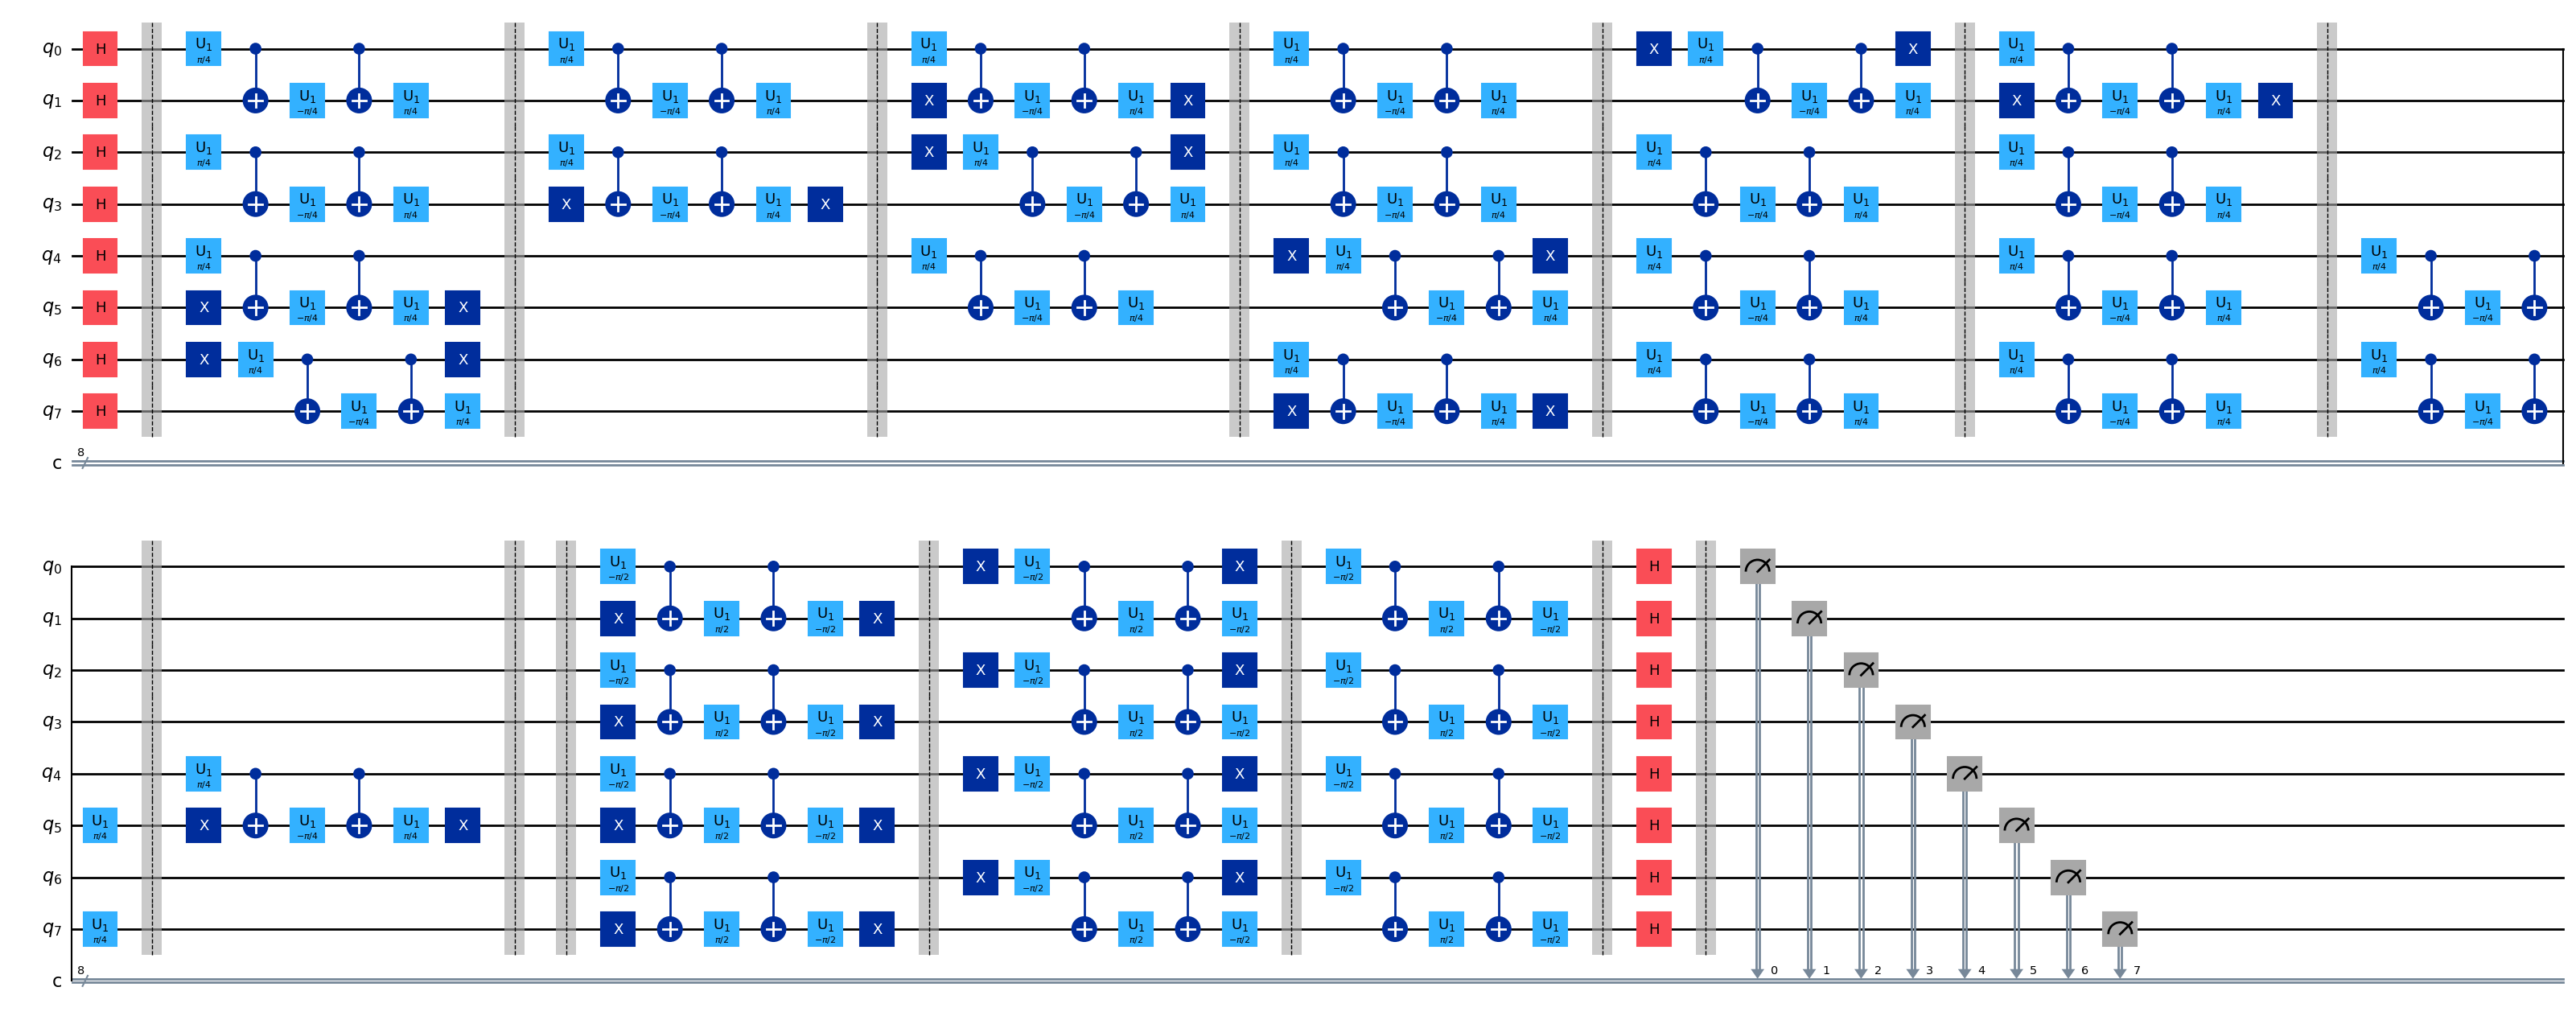

Saved: /Users/tangzhi/Desktop/Quafu/assets/circuits/imdb-parallel-qos-M8-P4-packed_P4.png


In [179]:
preview_bundle = experiment_bundles[PREVIEW_M]
preview_packed_circuit = preview_bundle["packed_circuit"]
draw_circuit = (
    preview_packed_circuit
    if P_SELECTED <= 4
    else preview_bundle["single_circuits"][0]
)
draw_label = (
    f"packed_P{P_SELECTED}"
    if P_SELECTED <= 4
    else "representative_pair0"
)
try:
    figure = draw_circuit.draw(
        output="mpl",
        fold=48,
        idle_wires=False,
    )
    circuit_path = (
        PROJECT_ROOT
        / "assets/circuits"
        / (
            f"imdb-parallel-qos-M{PREVIEW_M}-"
            f"P{P_SELECTED}-{draw_label}.png"
        )
    )
    circuit_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        circuit_path, dpi=180, bbox_inches="tight"
    )
    display(figure)
    print("Saved:", circuit_path)
except Exception as exc:
    print("mpl circuit drawing unavailable:", exc)
    print(draw_circuit.draw(output="text", fold=120))


## 3. 六任务预检与 campaign ladder

一次 `submit` 会顺序调用六次 API，并不是平台原子 batch。真正联网前，
notebook 会先对六个 QASM 全部完成 hash、宽度、measurement、跨-pair
二比特门和 statevector block 审计。

默认按 $P=1\rightarrow2\rightarrow4\rightarrow8\rightarrow16$
逐级进行。提交更大的 $P$ 之前，上一个 $P$ 的六个 $M$ 必须全部：

1. 已成功 fetch；
2. joint counts 解析和 shots 检查通过；
3. returned measurement mapping 完整；
4. returned QASM 的严格 pair-isolation 审计通过。

`target_qubits` 的列表顺序不被当作固定 logical-to-physical mapping。
实际物理 pairs 必须等 fetch 后从 returned QASM 解析。


In [180]:
def read_json_list(path):
    if not path.exists():
        return []
    payload = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(payload, list):
        raise ValueError(f"Expected JSON list: {path}")
    return payload


def upsert_json_rows(path, rows, key_function):
    existing = read_json_list(path)
    combined = {
        key_function(item): item for item in existing
    }
    for row in rows:
        combined[key_function(row)] = row
    output = list(combined.values())
    write_json_atomic(path, output)
    return output


def valid_task_id(value):
    return (
        isinstance(value, (int, np.integer))
        and not isinstance(value, (bool, np.bool_))
        and int(value) > 0
    )


def reconcile_registry_from_receipts():
    registry = read_json_list(REGISTRY_PATH)
    known_ids = {
        int(item["task_id"])
        for item in registry
        if valid_task_id(item.get("task_id"))
    }
    recovered = []
    for receipt_path in RAW_RESULT_DIR.glob("receipt_*.json"):
        try:
            record = json.loads(
                receipt_path.read_text(encoding="utf-8")
            )
        except Exception:
            continue
        if (
            record.get("campaign_label") == CAMPAIGN_LABEL
            and valid_task_id(record.get("task_id"))
            and int(record["task_id"]) not in known_ids
        ):
            recovered.append(record)
            known_ids.add(int(record["task_id"]))
    if recovered:
        for recovered_record in recovered:
            retry_of = recovered_record.get(
                "retry_of_task_id"
            )
            if valid_task_id(retry_of):
                updated = []
                for item in registry:
                    if (
                        valid_task_id(item.get("task_id"))
                        and int(item["task_id"])
                        == int(retry_of)
                    ):
                        item = {
                            **item,
                            "active": False,
                            "superseded_by_task_id": int(
                                recovered_record["task_id"]
                            ),
                            "superseded_at_utc": (
                                recovered_record.get(
                                    "submitted_at_utc"
                                )
                            ),
                            "superseded_reason": (
                                recovered_record.get(
                                    "replacement_reason",
                                    "retry_receipt_recovery",
                                )
                            ),
                        }
                    updated.append(item)
                registry = updated
            registry.append(recovered_record)
        write_json_atomic(REGISTRY_PATH, registry)
        print(
            "Recovered registry records from receipts:",
            [item["task_id"] for item in recovered],
        )
    return registry


def previous_p_value(p_value):
    smaller = [value for value in P_VALUES if value < p_value]
    return max(smaller) if smaller else None


def row_int(row, key, default=-1):
    try:
        return int(row.get(key, default))
    except (TypeError, ValueError):
        return default


def previous_p_gate():
    previous = previous_p_value(P_SELECTED)
    if previous is None:
        return {
            "required": False,
            "previous_P": None,
            "required_M": list(M_VALUES),
            "successful_M": list(M_VALUES),
            "missing_M": [],
            "pass": True,
            "reason": "P=1 has no predecessor",
        }
    if not REQUIRE_PREVIOUS_P_SUCCESS or ALLOW_SKIP_LADDER:
        return {
            "required": False,
            "previous_P": previous,
            "required_M": list(M_VALUES),
            "successful_M": [],
            "missing_M": [],
            "pass": True,
            "reason": "ladder explicitly bypassed",
        }

    rows = [
        row
        for row in read_json_list(TASK_RESULTS_JSON)
        if row.get("schema_version") == SCHEMA_VERSION
        and row.get("design_id") == DESIGN_ID
        and row.get("campaign_label") == CAMPAIGN_LABEL
        and row_int(row, "P_parallel_streams") == previous
        and row_int(row, "M_data_per_stream") in M_VALUES
        and row_int(row, "base_stream_seed")
        == BASE_STREAM_SEED
        and row_int(row, "replicate_id") == REPLICATE_ID
        and row.get("assignment_id") == ASSIGNMENT_ID
        and row.get("backend") == BACKEND
        and row.get("compiler") == COMPILER
        and row_int(row, "shots_requested") == SHOTS
        and row.get("fetch_reason") == "ok"
        and bool(row.get("analysis_eligible"))
        and bool(row.get("layout_audit_pass"))
    ]
    successful_m = sorted(
        {row_int(row, "M_data_per_stream") for row in rows}
    )
    missing_m = [
        m_data
        for m_data in M_VALUES
        if m_data not in successful_m
    ]
    return {
        "required": True,
        "previous_P": previous,
        "required_M": list(M_VALUES),
        "successful_M": successful_m,
        "missing_M": missing_m,
        "pass": not missing_m,
        "reason": (
            "previous P has six successful audited M tasks"
            if not missing_m
            else (
                f"P={previous} is missing successful audited "
                f"M={missing_m}"
            )
        ),
    }


ladder_gate = previous_p_gate()
display(pd.Series(ladder_gate, name="campaign ladder").to_frame())

audit_failures = [
    m_data
    for m_data in M_VALUES
    if not experiment_bundles[m_data]["audit"][
        "offline_audit_pass"
    ]
]
if audit_failures:
    raise RuntimeError(
        f"Offline audit failed for M={audit_failures}."
    )
if len(run_plans) != 6:
    raise AssertionError("Current P must have exactly six run plans.")

run_plan_frame = pd.DataFrame(
    [
        {
            "enabled": plan["enabled"],
            "grid_cell": plan["grid_cell_id"],
            "P": plan["P_parallel_streams"],
            "M": plan["M_data_per_stream"],
            "logical_width": plan["logical_width"],
            "shots": plan["shots"],
            "compiler": plan["compiler"],
            "target_qubits": plan["target_qubits"],
            "fingerprint_12": plan[
                "fingerprint_sha256"
            ][:12],
        }
        for plan in run_plans
    ]
)
display(run_plan_frame)
display(
    pd.Series(
        {
            "submission_batch_id": batch_id,
            "P": P_SELECTED,
            "M_values": list(M_VALUES),
            "new tasks in a fresh batch": 6,
            "logical width": 2 * P_SELECTED,
            "batch digest": batch_digest,
            "digest confirmation": batch_digest[:12],
            "fresh confirmation": (
                expected_submit_confirmation
            ),
            "resume confirmation": (
                expected_resume_confirmation
            ),
            "retry M": list(retry_m_values),
            "retry confirmation": (
                expected_retry_confirmation
                if expected_retry_confirmation
                else "disabled"
            ),
        },
        name="six-task batch safety",
    ).to_frame()
)

if ACTION in {"submit", "retry"} and not ladder_gate["pass"]:
    raise RuntimeError(
        "Campaign ladder blocked submission: "
        + ladder_gate["reason"]
    )


,campaign ladder
required,True
previous_P,2
required_M,"[4, 8, 16, 32, 64, 96]"
successful_M,"[4, 8, 16, 32, 64, 96]"
missing_M,[]
pass,True
reason,previous P has six successful audited M tasks


,enabled,grid_cell,P,M,logical_width,shots,compiler,target_qubits,fingerprint_12
0,True,P4_M4,4,4,8,4096,qsteed,[],5c6ac1b90562
1,True,P4_M8,4,8,8,4096,qsteed,[],0469a754b2cd
2,True,P4_M16,4,16,8,4096,qsteed,[],834130ed4316
3,True,P4_M32,4,32,8,4096,qsteed,[],5d6668a43ccc
4,True,P4_M64,4,64,8,4096,qsteed,[],d3db2aa2e5e0
5,True,P4_M96,4,96,8,4096,qsteed,[],d81113670de0


,six-task batch safety
submission_batch_id,imdb_parallel_qos_grid_001_P4_7a87d3d77c54
P,4
M_values,"[4, 8, 16, 32, 64, 96]"
new tasks in a fresh batch,6
logical width,8
batch digest,7a87d3d77c54241d50001d6bdd8abc98b548357a5e9bb8...
digest confirmation,7a87d3d77c54
fresh confirmation,SUBMIT_6_TASKS_FOR_P_4
resume confirmation,RESUME_MISSING_TASKS_FOR_P_4
retry M,[]


## 4. 建立可选网络会话

`dry_run` 完全离线，不需要 token。`status`、`submit`、`fetch` 才会读取
环境变量 `QPU_API_TOKEN`；如果没有设置，会使用隐藏输入框。

`submit` 会检查当前 backend 可用性。`fetch` 即使 backend 后来进入维护，
仍可尝试读取已经完成的历史任务。


In [181]:
NETWORK_ACTIONS = {"status", "submit", "retry", "fetch"}
task_manager = None
backend_snapshot = None


def normalized_status(value):
    if isinstance(value, dict):
        for key in ("status", "state", "task_status"):
            if key in value:
                return str(value[key]).strip().lower()
    return str(value).strip().lower()


FINISHED_STATES = {
    "finished",
    "completed",
    "complete",
    "success",
    "succeeded",
}
FAILED_STATES = {
    "failed",
    "error",
    "cancelled",
    "canceled",
}


def backend_value_is_available(value):
    if isinstance(value, (int, np.integer)):
        return int(value) >= 0
    text = str(value).strip().lower()
    return text in {
        "online",
        "available",
        "idle",
        "ready",
    } or text.isdigit()


if ACTION in NETWORK_ACTIONS:
    token = os.getenv("QPU_API_TOKEN", "").strip()
    if not token:
        token = getpass("Quafu-SQC token: ").strip()
    if not token:
        raise ValueError("A Quafu-SQC token is required.")

    from quafu import Task

    task_manager = Task(token)

    # Only status/submit need the live backend queue snapshot.
    if ACTION in {"status", "submit", "retry"}:
        backend_snapshot = task_manager.status()
        if not isinstance(backend_snapshot, dict):
            raise RuntimeError(
                "Backend status endpoint returned an invalid payload."
            )
        snapshot_path = (
            RAW_RESULT_DIR
            / (
                "backend_status_"
                + datetime.now(timezone.utc).strftime(
                    "%Y%m%dT%H%M%SZ"
                )
                + ".json"
            )
        )
        RAW_RESULT_DIR.mkdir(parents=True, exist_ok=True)
        write_json_atomic(snapshot_path, backend_snapshot)
        display(
            pd.Series(
                backend_snapshot, name="queue/status"
            ).to_frame()
        )
        if BACKEND not in backend_snapshot:
            raise RuntimeError(
                f"Backend {BACKEND!r} is absent from status."
            )
        if (
            ACTION in {"submit", "retry"}
            and not backend_value_is_available(
                backend_snapshot[BACKEND]
            )
        ):
            raise RuntimeError(
                f"Backend {BACKEND!r} is not available: "
                f"{backend_snapshot[BACKEND]!r}"
            )
else:
    print("Offline mode: no token and no network request.")


## 5. 六任务提交、registry 与状态

`ACTION="submit"` 时，当前 $P$ 的六个 $M$ 会按从浅到深的顺序
逐个提交。每次 API 返回 task ID 后，notebook 会立刻写：

- 独立 receipt JSON；
- `task_registry.json`；
- 对应 submission-intent 的最终状态。

fingerprint 绑定 campaign、$P$、$M$、QASM hash、stream hash、shots、
compiler 和布局请求。完整重复任务默认禁止。

这六次 API 调用不是原子事务。如果中途失败，已提交任务仍然有效；
默认停止并要求先核对 registry。之后可显式开启
`RESUME_PARTIAL_BATCH=True`，只补交缺失的 $M$。


In [182]:
def read_registry():
    return reconcile_registry_from_receipts()


def record_is_active(record):
    return bool(record.get("active", True)) and not (
        valid_task_id(record.get("superseded_by_task_id"))
    )


def all_records_for_plan(registry, plan):
    fingerprint = plan["fingerprint_sha256"]
    return [
        record
        for record in registry
        if valid_task_id(record.get("task_id"))
        and record.get("fingerprint_sha256")
        == fingerprint
    ]


def records_for_plan(registry, plan):
    return [
        record
        for record in all_records_for_plan(registry, plan)
        if record_is_active(record)
    ]


def ambiguous_intents_for_current_batch(registry):
    output = []
    registered_fingerprints = {
        record.get("fingerprint_sha256")
        for record in registry
        if valid_task_id(record.get("task_id"))
    }
    for path in INTENT_DIR.glob(
        f"intent_{batch_id}_M*.json"
    ):
        try:
            payload = json.loads(
                path.read_text(encoding="utf-8")
            )
        except Exception as exc:
            raise RuntimeError(
                "Unreadable submission intent; fail-closed "
                f"before submission: {path}: "
                f"{type(exc).__name__}: {exc}"
            ) from exc
        state = payload.get("state")
        has_registered_record = (
            payload.get("fingerprint_sha256")
            in registered_fingerprints
        )
        if (
            state in {"submitting", "ambiguous"}
            and not has_registered_record
        ):
            output.append(payload)
    return output



def result_row_for_task(task_id):
    rows = [
        row
        for row in read_json_list(TASK_RESULTS_JSON)
        if valid_task_id(row.get("task_id"))
        and int(row["task_id"]) == int(task_id)
    ]
    return rows[-1] if rows else {}


def register_retry_replacement(
    registry,
    plan,
    old_record,
    new_task_id,
    task_name,
    attempt_id,
    submitted_at_utc,
    replacement_reason,
    submission_status,
):
    new_task_id = int(new_task_id)
    old_task_id = int(old_record["task_id"])
    conflicts = [
        item
        for item in registry
        if valid_task_id(item.get("task_id"))
        and int(item["task_id"]) == new_task_id
    ]
    if conflicts:
        raise RuntimeError(
            f"Replacement task ID {new_task_id} is already registered."
        )

    history = all_records_for_plan(registry, plan)
    retry_index = 1 + max(
        [int(item.get("retry_index", 0)) for item in history]
        or [0]
    )
    new_record = {
        **plan,
        "task_id": new_task_id,
        "task_name": task_name,
        "attempt_id": attempt_id,
        "submitted_at_utc": submitted_at_utc,
        "submission_status": submission_status,
        "environment": ENVIRONMENT,
        "active": True,
        "retry_index": retry_index,
        "retry_of_task_id": old_task_id,
        "replacement_reason": replacement_reason,
    }
    receipt_path = (
        RAW_RESULT_DIR
        / (
            f"receipt_retry_{plan['run_label']}_"
            f"{new_task_id}.json"
        )
    )
    new_record["receipt_path"] = str(
        receipt_path.relative_to(PROJECT_ROOT)
    )
    # Receipt first: if the kernel stops before registry replacement,
    # reconcile_registry_from_receipts() can finish the transaction.
    write_json_atomic(receipt_path, new_record)

    updated_registry = []
    old_found = False
    for item in registry:
        if (
            valid_task_id(item.get("task_id"))
            and int(item["task_id"]) == old_task_id
        ):
            item = {
                **item,
                "active": False,
                "superseded_by_task_id": new_task_id,
                "superseded_at_utc": submitted_at_utc,
                "superseded_reason": replacement_reason,
            }
            old_found = True
        updated_registry.append(item)
    if not old_found:
        raise RuntimeError(
            f"Old task ID {old_task_id} disappeared before replacement."
        )
    updated_registry.append(new_record)
    write_json_atomic(REGISTRY_PATH, updated_registry)
    return updated_registry, new_record


retried_records = []
if ACTION == "retry":
    if CONFIRM_REAL_SUBMISSION != expected_retry_confirmation:
        raise ValueError(
            "Set CONFIRM_REAL_SUBMISSION exactly to "
            f"{expected_retry_confirmation!r}."
        )
    if CONFIRM_BATCH_DIGEST != batch_digest[:12]:
        raise ValueError(
            "Set CONFIRM_BATCH_DIGEST to the current P batch's "
            "12-character value."
        )
    if len(retry_m_values) > MAX_TASKS_PER_RETRY:
        raise RuntimeError("Retry exceeds the six-task safety limit.")

    registry = read_registry()
    plans_by_m = {
        int(plan["M_data_per_stream"]): plan
        for plan in run_plans
    }
    retry_targets = []
    preflight_rows = []
    for m_data in retry_m_values:
        plan = plans_by_m[m_data]
        matches = records_for_plan(registry, plan)
        if len(matches) != 1:
            raise RuntimeError(
                "Retry requires exactly one active task for "
                f"P={P_SELECTED}, M={m_data}; found {len(matches)}."
            )
        old_record = matches[0]
        old_task_id = int(old_record["task_id"])
        try:
            live_status = task_manager.status(old_task_id)
        except Exception as exc:
            raise RuntimeError(
                f"Cannot verify old task {old_task_id} before retry: "
                f"{type(exc).__name__}: {exc}"
            ) from exc
        state = normalized_status(live_status)
        old_result = result_row_for_task(old_task_id)
        fetch_reason = str(old_result.get("fetch_reason", ""))
        replacement_reason = (
            f"failed_status:{state}"
            if state in FAILED_STATES
            else fetch_reason
        )
        eligible = bool(
            state in FAILED_STATES
            or fetch_reason == "audit_failed"
        )
        preflight_rows.append(
            {
                "P": P_SELECTED,
                "M": m_data,
                "old_task_id": old_task_id,
                "live_status": live_status,
                "fetch_reason": fetch_reason,
                "retry_eligible": eligible,
                "replacement_reason": replacement_reason,
            }
        )
        if not eligible:
            raise RuntimeError(
                "Retry blocked: the active task is not terminal-failed "
                "and has no audit_failed result: "
                f"P={P_SELECTED}, M={m_data}, task_id={old_task_id}, "
                f"status={live_status!r}, fetch_reason={fetch_reason!r}."
            )
        retry_targets.append(
            (m_data, plan, old_record, replacement_reason)
        )
    display(pd.DataFrame(preflight_rows).sort_values("M"))

    for m_data, plan, old_record, replacement_reason in retry_targets:
        old_task_id = int(old_record["task_id"])
        unresolved_paths = []
        for path in INTENT_DIR.glob(
            f"retry_intent_{batch_id}_M{m_data}_"
            f"from{old_task_id}_*.json"
        ):
            try:
                payload = json.loads(
                    path.read_text(encoding="utf-8")
                )
            except Exception as exc:
                raise RuntimeError(
                    "Unreadable retry intent; fail-closed: "
                    f"{path}: {type(exc).__name__}: {exc}"
                ) from exc
            if payload.get("state") in {"submitting", "ambiguous"}:
                unresolved_paths.append((path, payload))

        if unresolved_paths:
            if len(unresolved_paths) > 1:
                raise RuntimeError(
                    f"Multiple unresolved retry intents for M={m_data}."
                )
            intent_path, intent = unresolved_paths[0]
            if m_data in RECOVER_RETRY_TASK_IDS_BY_M:
                recovered_task_id = int(
                    RECOVER_RETRY_TASK_IDS_BY_M[m_data]
                )
                registry, recovered_record = register_retry_replacement(
                    registry=registry,
                    plan=plan,
                    old_record=old_record,
                    new_task_id=recovered_task_id,
                    task_name=intent["task_name"],
                    attempt_id=intent["attempt_id"],
                    submitted_at_utc=intent["created_at_utc"],
                    replacement_reason=replacement_reason,
                    submission_status="retry_recovered_manual",
                )
                intent.update(
                    {
                        "state": "recovered_manual",
                        "task_id": recovered_task_id,
                        "receipt_path": recovered_record["receipt_path"],
                        "updated_at_utc": datetime.now(
                            timezone.utc
                        ).isoformat(),
                    }
                )
                write_json_atomic(intent_path, intent)
                retried_records.append(recovered_record)
                print(
                    f"Recovered retry M={m_data}: "
                    f"task_id={recovered_task_id}"
                )
                continue
            if m_data in RETRY_M_VERIFIED_NOT_SUBMITTED:
                intent.update(
                    {
                        "state": "resolved_not_submitted_by_user",
                        "updated_at_utc": datetime.now(
                            timezone.utc
                        ).isoformat(),
                    }
                )
                write_json_atomic(intent_path, intent)
            else:
                raise RuntimeError(
                    "Unresolved retry intent for "
                    f"M={m_data}, old task_id={old_task_id}. Check "
                    "the platform by task_name, then fill either "
                    "RECOVER_RETRY_TASK_IDS_BY_M or "
                    "RETRY_M_VERIFIED_NOT_SUBMITTED."
                )

        timestamp = datetime.now(timezone.utc)
        attempt_id = uuid4().hex
        task_name = (
            f"qos_pm_retry_P{P_SELECTED}_M{m_data}_"
            f"{timestamp.strftime('%m%dT%H%M%S')}_"
            f"{attempt_id[:6]}"
        )[:80]
        intent_path = (
            INTENT_DIR
            / (
                f"retry_intent_{batch_id}_M{m_data}_"
                f"from{old_task_id}_{attempt_id[:8]}.json"
            )
        )
        intent = {
            "schema_version": SCHEMA_VERSION,
            "design_id": DESIGN_ID,
            "campaign_label": CAMPAIGN_LABEL,
            "submission_batch_id": batch_id,
            "batch_digest": batch_digest,
            "attempt_id": attempt_id,
            "grid_cell_id": plan["grid_cell_id"],
            "P_parallel_streams": P_SELECTED,
            "M_data_per_stream": m_data,
            "task_name": task_name,
            "fingerprint_sha256": plan["fingerprint_sha256"],
            "retry_of_task_id": old_task_id,
            "replacement_reason": replacement_reason,
            "created_at_utc": timestamp.isoformat(),
            "state": "submitting",
            "intent_path": str(
                intent_path.relative_to(PROJECT_ROOT)
            ),
        }
        write_json_atomic(intent_path, intent)

        qasm_text = experiment_bundles[m_data][
            "qasm_path"
        ].read_text(encoding="utf-8")
        if sha256_text(qasm_text) != plan["qasm_sha256"]:
            raise RuntimeError(
                f"QASM hash mismatch before retry M={m_data}."
            )
        task = {
            "chip": BACKEND,
            "name": task_name,
            "circuit": qasm_text,
            "shots": int(SHOTS),
            "compile": True,
            "options": {
                "compiler": COMPILER,
                "correct": bool(USE_READOUT_CORRECTION),
                "open_dd": OPEN_DD,
                "target_qubits": target_qubits,
            },
        }
        try:
            new_task_id = task_manager.run(task)
            if not valid_task_id(new_task_id):
                raise RuntimeError(
                    "Retry did not return a positive task ID: "
                    f"{new_task_id!r}"
                )
        except Exception as exc:
            intent.update(
                {
                    "state": "ambiguous",
                    "exception_type": type(exc).__name__,
                    "exception": str(exc),
                    "updated_at_utc": datetime.now(
                        timezone.utc
                    ).isoformat(),
                }
            )
            write_json_atomic(intent_path, intent)
            raise RuntimeError(
                "Retry stopped after an ambiguous API response at "
                f"M={m_data}. Check the platform by task_name before "
                "any further retry."
            ) from exc

        registry, new_record = register_retry_replacement(
            registry=registry,
            plan=plan,
            old_record=old_record,
            new_task_id=int(new_task_id),
            task_name=task_name,
            attempt_id=attempt_id,
            submitted_at_utc=timestamp.isoformat(),
            replacement_reason=replacement_reason,
            submission_status="retry_submitted",
        )
        intent.update(
            {
                "state": "registered",
                "task_id": int(new_task_id),
                "receipt_path": new_record["receipt_path"],
                "updated_at_utc": datetime.now(
                    timezone.utc
                ).isoformat(),
            }
        )
        write_json_atomic(intent_path, intent)
        retried_records.append(new_record)
        print(
            f"Retried M={m_data}: old task_id={old_task_id}, "
            f"new task_id={int(new_task_id)}"
        )

    print(
        "Retry pass complete. New active task IDs:",
        [int(item["task_id"]) for item in retried_records],
    )
else:
    print("Retry inactive for ACTION =", ACTION)


submitted_records = []
if ACTION == "submit":
    registry = read_registry()
    ambiguous_intents = (
        ambiguous_intents_for_current_batch(registry)
    )
    resolved_ambiguous = False
    if ambiguous_intents:
        unresolved = []
        for intent in ambiguous_intents:
            intent_m = int(
                intent["M_data_per_stream"]
            )
            if (
                intent_m not in RECOVER_TASK_IDS_BY_M
                and intent_m
                not in AMBIGUOUS_M_VERIFIED_NOT_SUBMITTED
            ):
                unresolved.append(intent_m)
        if unresolved:
            raise RuntimeError(
                "Ambiguous submission intents remain for "
                f"M={sorted(unresolved)}. Check the platform "
                "by task_name, then either fill "
                "RECOVER_TASK_IDS_BY_M or "
                "AMBIGUOUS_M_VERIFIED_NOT_SUBMITTED."
            )
        if (
            not RESUME_PARTIAL_BATCH
            or CONFIRM_REAL_SUBMISSION
            != expected_resume_confirmation
            or CONFIRM_BATCH_DIGEST
            != batch_digest[:12]
        ):
            raise RuntimeError(
                "Resolving an ambiguous intent requires "
                "RESUME_PARTIAL_BATCH=True, the resume "
                "confirmation phrase and the matching "
                "12-character batch digest."
            )

        plans_by_m = {
            int(plan["M_data_per_stream"]): plan
            for plan in run_plans
        }
        for intent in ambiguous_intents:
            intent_m = int(
                intent["M_data_per_stream"]
            )
            intent_path = (
                PROJECT_ROOT / intent["intent_path"]
            )
            if intent_m in RECOVER_TASK_IDS_BY_M:
                recovered_task_id = int(
                    RECOVER_TASK_IDS_BY_M[intent_m]
                )
                conflicting_ids = [
                    row
                    for row in registry
                    if valid_task_id(row.get("task_id"))
                    and int(row["task_id"])
                    == recovered_task_id
                    and row.get("fingerprint_sha256")
                    != intent["fingerprint_sha256"]
                ]
                if conflicting_ids:
                    raise RuntimeError(
                        "Recovered task ID is already bound "
                        "to another fingerprint."
                    )
                plan = plans_by_m[intent_m]
                matches = records_for_plan(
                    registry, plan
                )
                if not matches:
                    recovered_record = {
                        **plan,
                        "task_id": recovered_task_id,
                        "task_name": intent["task_name"],
                        "attempt_id": intent[
                            "attempt_id"
                        ],
                        "submitted_at_utc": intent[
                            "created_at_utc"
                        ],
                        "submission_status": (
                            "recovered_manual"
                        ),
                        "environment": ENVIRONMENT,
                        "active": True,
                        "retry_index": 0,
                    }
                    receipt_path = (
                        RAW_RESULT_DIR
                        / (
                            "receipt_recovered_"
                            f"{plan['run_label']}_"
                            f"{recovered_task_id}.json"
                        )
                    )
                    recovered_record[
                        "receipt_path"
                    ] = str(
                        receipt_path.relative_to(
                            PROJECT_ROOT
                        )
                    )
                    write_json_atomic(
                        receipt_path,
                        recovered_record,
                    )
                    registry.append(recovered_record)
                    write_json_atomic(
                        REGISTRY_PATH, registry
                    )
                intent.update(
                    {
                        "state": "recovered_manual",
                        "task_id": recovered_task_id,
                        "updated_at_utc": datetime.now(
                            timezone.utc
                        ).isoformat(),
                    }
                )
            else:
                intent.update(
                    {
                        "state": (
                            "resolved_not_submitted_by_user"
                        ),
                        "updated_at_utc": datetime.now(
                            timezone.utc
                        ).isoformat(),
                    }
                )
            write_json_atomic(intent_path, intent)
        resolved_ambiguous = True
        registry = read_registry()

    existing_by_m = {}
    missing_plans = []
    for plan in run_plans:
        matches = records_for_plan(registry, plan)
        if len(matches) > 1:
            raise RuntimeError(
                "Multiple task IDs share one fingerprint for "
                f"M={plan['M_data_per_stream']}: "
                f"{[item['task_id'] for item in matches]}"
            )
        if matches:
            existing_by_m[
                int(plan["M_data_per_stream"])
            ] = matches[0]
        else:
            missing_plans.append(plan)

    if not missing_plans:
        raise RuntimeError(
            "All six tasks are already registered for this "
            "P/config. Use ACTION='status' or 'fetch'."
        )
    if len(missing_plans) > MAX_TASKS_PER_SUBMISSION:
        raise RuntimeError(
            "Submission exceeds the six-task safety limit."
        )

    partial = bool(existing_by_m) or resolved_ambiguous
    if partial and not RESUME_PARTIAL_BATCH:
        raise RuntimeError(
            "This is a partial batch. Existing M="
            f"{sorted(existing_by_m)}; missing M="
            f"{[p['M_data_per_stream'] for p in missing_plans]}. "
            "After checking the registry, set "
            "RESUME_PARTIAL_BATCH=True and use the displayed "
            "resume confirmation."
        )

    expected_confirmation = (
        expected_resume_confirmation
        if partial
        else expected_submit_confirmation
    )
    if CONFIRM_REAL_SUBMISSION != expected_confirmation:
        raise ValueError(
            "Set CONFIRM_REAL_SUBMISSION exactly to "
            f"{expected_confirmation!r}."
        )
    if CONFIRM_BATCH_DIGEST != batch_digest[:12]:
        raise ValueError(
            "Set CONFIRM_BATCH_DIGEST to the 12-character "
            "value printed by dry_run."
        )

    print(
        "Submitting missing M values:",
        [
            int(plan["M_data_per_stream"])
            for plan in missing_plans
        ],
    )
    submission_failure = None
    for plan in missing_plans:
        m_data = int(plan["M_data_per_stream"])
        bundle = experiment_bundles[m_data]
        qasm_text = bundle["qasm_path"].read_text(
            encoding="utf-8"
        )
        if sha256_text(qasm_text) != plan["qasm_sha256"]:
            raise RuntimeError(
                f"QASM hash mismatch before M={m_data} "
                "submission."
            )
        if not bundle["audit"]["offline_audit_pass"]:
            raise RuntimeError(
                f"Offline audit failed before M={m_data}."
            )

        timestamp = datetime.now(timezone.utc)
        attempt_id = uuid4().hex
        task_name = (
            f"qos_pm_P{P_SELECTED}_M{m_data}_"
            f"{timestamp.strftime('%m%dT%H%M%S')}_"
            f"{attempt_id[:6]}"
        )[:80]
        intent_path = (
            INTENT_DIR
            / f"intent_{batch_id}_M{m_data}.json"
        )
        intent = {
            "schema_version": SCHEMA_VERSION,
            "design_id": DESIGN_ID,
            "campaign_label": CAMPAIGN_LABEL,
            "submission_batch_id": batch_id,
            "batch_digest": batch_digest,
            "attempt_id": attempt_id,
            "grid_cell_id": plan["grid_cell_id"],
            "P_parallel_streams": P_SELECTED,
            "M_data_per_stream": m_data,
            "task_name": task_name,
            "fingerprint_sha256": plan[
                "fingerprint_sha256"
            ],
            "created_at_utc": timestamp.isoformat(),
            "state": "submitting",
            "intent_path": str(
                intent_path.relative_to(PROJECT_ROOT)
            ),
        }
        write_json_atomic(intent_path, intent)

        task = {
            "chip": BACKEND,
            "name": task_name,
            "circuit": qasm_text,
            "shots": int(SHOTS),
            "compile": True,
            "options": {
                "compiler": COMPILER,
                "correct": bool(
                    USE_READOUT_CORRECTION
                ),
                "open_dd": OPEN_DD,
                "target_qubits": target_qubits,
            },
        }
        try:
            task_id = task_manager.run(task)
            if not valid_task_id(task_id):
                raise RuntimeError(
                    "Submission did not return a positive "
                    f"task ID: {task_id!r}"
                )
        except Exception as exc:
            intent.update(
                {
                    "state": "ambiguous",
                    "exception_type": type(exc).__name__,
                    "exception": str(exc),
                    "updated_at_utc": datetime.now(
                        timezone.utc
                    ).isoformat(),
                }
            )
            write_json_atomic(intent_path, intent)
            submission_failure = (
                m_data,
                type(exc).__name__,
                str(exc),
            )
            break

        submitted_record = {
            **plan,
            "task_id": int(task_id),
            "task_name": task_name,
            "attempt_id": attempt_id,
            "submitted_at_utc": timestamp.isoformat(),
            "submission_status": "submitted",
            "environment": ENVIRONMENT,
            "active": True,
            "retry_index": 0,
        }
        receipt_path = (
            RAW_RESULT_DIR
            / (
                f"receipt_{plan['run_label']}_"
                f"{task_id}.json"
            )
        )
        submitted_record["receipt_path"] = str(
            receipt_path.relative_to(PROJECT_ROOT)
        )
        write_json_atomic(
            receipt_path, submitted_record
        )

        registry.append(submitted_record)
        write_json_atomic(REGISTRY_PATH, registry)
        intent.update(
            {
                "state": "registered",
                "task_id": int(task_id),
                "receipt_path": submitted_record[
                    "receipt_path"
                ],
                "updated_at_utc": datetime.now(
                    timezone.utc
                ).isoformat(),
            }
        )
        write_json_atomic(intent_path, intent)
        submitted_records.append(submitted_record)
        print(
            f"Submitted M={m_data}: task_id={int(task_id)}"
        )

    if submission_failure is not None:
        failed_m, failure_type, failure_text = (
            submission_failure
        )
        raise RuntimeError(
            "Batch stopped after an ambiguous submission "
            f"at M={failed_m}: {failure_type}: "
            f"{failure_text}. Already returned task IDs were "
            "persisted. Check the platform task list using "
            "the task_name in the intent before any retry."
        )

    print(
        "Submission pass complete. New task IDs:",
        [
            int(record["task_id"])
            for record in submitted_records
        ],
    )
else:
    print("Submission inactive for ACTION =", ACTION)


if ACTION == "status":
    registry = read_registry()
    result_rows_by_id = {
        int(row["task_id"]): row
        for row in read_json_list(TASK_RESULTS_JSON)
        if valid_task_id(row.get("task_id"))
    }
    status_rows = []
    for plan in run_plans:
        matches = records_for_plan(registry, plan)
        if len(matches) > 1:
            status_rows.append(
                {
                    "P": P_SELECTED,
                    "M": plan["M_data_per_stream"],
                    "task_id": None,
                    "live_status": "duplicate_registry",
                    "fetch_reason": "",
                    "layout_audit": False,
                }
            )
            continue
        if not matches:
            status_rows.append(
                {
                    "P": P_SELECTED,
                    "M": plan["M_data_per_stream"],
                    "task_id": None,
                    "live_status": "missing",
                    "fetch_reason": "",
                    "layout_audit": False,
                }
            )
            continue
        record = matches[0]
        task_id = int(record["task_id"])
        result_row = result_rows_by_id.get(task_id, {})
        try:
            live_status = task_manager.status(task_id)
        except Exception as exc:
            live_status = (
                f"status_error:{type(exc).__name__}:{exc}"
            )
        status_rows.append(
            {
                "P": P_SELECTED,
                "M": plan["M_data_per_stream"],
                "task_id": task_id,
                "live_status": live_status,
                "fetch_reason": result_row.get(
                    "fetch_reason", ""
                ),
                "layout_audit": bool(
                    result_row.get(
                        "layout_audit_pass", False
                    )
                ),
                "submitted_at_utc": record.get(
                    "submitted_at_utc"
                ),
            }
        )
    display(
        pd.DataFrame(status_rows).sort_values("M")
    )


Retry inactive for ACTION = fetch
Submission inactive for ACTION = fetch


## 6. 联合 counts、物理布局与 returned QASM 解析

Quafu/Qiskit 风格 bitstring 通常显示为

$$
c_{2P-1}\cdots c_1c_0.
$$

因此 classical bit $c_j$ 通过 `bits[-1-j]` 读取。第 $r$ 个 pair
的成功事件只要求 `c[2r]` 和 `c[2r+1]` 同时为零；其他 pairs
必须被边缘化掉。

returned QASM 的 qreg 可能是整块芯片宽度，例如 `q[84]`。审计会
分开保存：

- QASM 是否可解析；
- classical measurement map 是否完整；
- 被测物理比特是否唯一；
- 是否有 SWAP；
- 是否存在测量 pair 之外的二比特边；
- 最终严格 `layout_audit_pass`。

即使某条线路审计失败，raw counts 与 returned QASM 仍会保存，
但该网格点不会进入主三维分析。


In [183]:
def wilson_interval(
    successes, total, z=1.959963984540054
):
    successes = float(successes)
    total = float(total)
    if total <= 0 or successes < 0 or successes > total:
        return (np.nan, np.nan)
    proportion = successes / total
    denominator = 1 + z * z / total
    center = (
        proportion + z * z / (2 * total)
    ) / denominator
    half_width = (
        z
        * math.sqrt(
            proportion * (1 - proportion) / total
            + z * z / (4 * total * total)
        )
        / denominator
    )
    return (
        max(0.0, center - half_width),
        min(1.0, center + half_width),
    )


def clean_joint_counts(counts, width):
    if not isinstance(counts, dict) or not counts:
        raise ValueError("Missing joint counts.")
    cleaned = {}
    for raw_bits, raw_value in counts.items():
        bits = str(raw_bits).replace(" ", "")
        if len(bits) != width or set(bits) - {"0", "1"}:
            raise ValueError(
                f"Expected a {width}-bit binary key, "
                f"got {raw_bits!r}."
            )
        if isinstance(raw_value, (bool, np.bool_)):
            raise ValueError("Boolean count is invalid.")
        numeric = float(raw_value)
        if (
            not np.isfinite(numeric)
            or numeric < 0
            or not numeric.is_integer()
        ):
            raise ValueError(
                f"Invalid raw count for {bits}: "
                f"{raw_value!r}"
            )
        cleaned[bits] = (
            cleaned.get(bits, 0) + int(numeric)
        )
    if sum(cleaned.values()) <= 0:
        raise ValueError("Counts total must be positive.")
    return cleaned


def cbit(display_bits, classical_index):
    return display_bits[-1 - int(classical_index)]


def parse_joint_counts(
    counts, p_value, expected_shots
):
    width = 2 * int(p_value)
    cleaned = clean_joint_counts(counts, width)
    total = int(sum(cleaned.values()))
    pair_success = np.zeros(p_value, dtype=float)
    sum_xx = np.zeros((p_value, p_value), dtype=float)
    sum_z = 0.0
    sum_z2 = 0.0
    marginals = [
        {"00": 0, "01": 0, "10": 0, "11": 0}
        for _ in range(p_value)
    ]

    for bits, weight in cleaned.items():
        x = np.zeros(p_value, dtype=float)
        for pair_index in range(p_value):
            low = cbit(bits, 2 * pair_index)
            high = cbit(bits, 2 * pair_index + 1)
            pair_bits = high + low
            marginals[pair_index][pair_bits] += weight
            x[pair_index] = float(pair_bits == "00")
        z_value = float(np.mean(x))
        pair_success += weight * x
        sum_xx += weight * np.outer(x, x)
        sum_z += weight * z_value
        sum_z2 += weight * z_value * z_value

    pair_rates = pair_success / total
    ensemble_mean = float(np.mean(pair_rates))
    if total > 1:
        covariance = (
            sum_xx
            - total * np.outer(pair_rates, pair_rates)
        ) / (total - 1)
        var_z = (
            sum_z2
            - total * (sum_z / total) ** 2
        ) / (total - 1)
    else:
        covariance = np.full(
            (p_value, p_value), np.nan
        )
        var_z = np.nan

    cluster_se = (
        math.sqrt(max(0.0, var_z) / total)
        if np.isfinite(var_z)
        else np.nan
    )
    marginal_variances = np.diag(covariance)
    naive_var = float(
        np.nansum(marginal_variances)
        / (p_value * p_value * total)
    )
    naive_se = (
        math.sqrt(max(0.0, naive_var))
        if np.isfinite(naive_var)
        else np.nan
    )
    z95 = 1.959963984540054
    cluster_low = max(
        0.0, ensemble_mean - z95 * cluster_se
    )
    cluster_high = min(
        1.0, ensemble_mean + z95 * cluster_se
    )

    if p_value > 1:
        standard_deviations = np.sqrt(
            np.clip(
                marginal_variances, 0.0, None
            )
        )
        denominator = np.outer(
            standard_deviations,
            standard_deviations,
        )
        correlation = np.divide(
            covariance,
            denominator,
            out=np.full_like(covariance, np.nan),
            where=denominator > 0,
        )
        mask = ~np.eye(p_value, dtype=bool)
        off_diagonal = correlation[mask]
        mean_signed_corr = float(
            np.nanmean(off_diagonal)
        )
        mean_abs_corr = float(
            np.nanmean(np.abs(off_diagonal))
        )
    else:
        correlation = np.asarray([[1.0]])
        mean_signed_corr = np.nan
        mean_abs_corr = np.nan

    average_variance = float(
        np.nanmean(marginal_variances)
    )
    effective_parallelism_raw = (
        average_variance / var_z
        if np.isfinite(var_z) and var_z > 0
        else np.nan
    )
    effective_parallelism_capped = (
        float(
            np.clip(
                effective_parallelism_raw,
                0.0,
                p_value,
            )
        )
        if np.isfinite(effective_parallelism_raw)
        else np.nan
    )
    parallel_efficiency_raw = (
        effective_parallelism_raw / p_value
        if np.isfinite(effective_parallelism_raw)
        else np.nan
    )
    parallel_efficiency_capped = (
        effective_parallelism_capped / p_value
        if np.isfinite(effective_parallelism_capped)
        else np.nan
    )
    design_effect = (
        (cluster_se / naive_se) ** 2
        if np.isfinite(cluster_se)
        and np.isfinite(naive_se)
        and naive_se > 0
        else np.nan
    )

    pair_rows = []
    for pair_index in range(p_value):
        successes = int(pair_success[pair_index])
        low, high = wilson_interval(successes, total)
        pair_rows.append(
            {
                "pair_index": pair_index,
                "successes_00": successes,
                "raw_F_echo": float(
                    pair_rates[pair_index]
                ),
                "raw_F_echo_ci_low": low,
                "raw_F_echo_ci_high": high,
                "raw_marginal_distribution": (
                    marginals[pair_index]
                ),
            }
        )

    return {
        "parse_reason": "ok",
        "counts_parse_pass": True,
        "shots_observed": total,
        "shots_match_manifest": (
            total == int(expected_shots)
        ),
        "ensemble_raw_F_echo": ensemble_mean,
        "ensemble_cluster_se": cluster_se,
        "ensemble_cluster_ci_low": cluster_low,
        "ensemble_cluster_ci_high": cluster_high,
        "ensemble_naive_independent_se": naive_se,
        "design_effect": design_effect,
        "mean_signed_offdiag_pair_corr": (
            mean_signed_corr
        ),
        "mean_abs_offdiag_pair_corr": mean_abs_corr,
        "effective_parallelism_raw": (
            effective_parallelism_raw
        ),
        "effective_parallelism": (
            effective_parallelism_raw
        ),
        "effective_parallelism_capped": (
            effective_parallelism_capped
        ),
        "parallel_efficiency_raw": (
            parallel_efficiency_raw
        ),
        "parallel_efficiency_capped": (
            parallel_efficiency_capped
        ),
        "pair_success_covariance": covariance.tolist(),
        "pair_success_correlation": correlation.tolist(),
        "joint_all_zero_probability": (
            cleaned.get("0" * width, 0) / total
        ),
        "raw_joint_distribution": cleaned,
        "pair_rows": pair_rows,
    }


MEASURE_PATTERN = re.compile(
    r"measure\s+[A-Za-z_]\w*\[(\d+)\]\s*"
    r"->\s*[A-Za-z_]\w*\[(\d+)\]\s*;"
)


def returned_qasm_metrics(qasm_text, p_value):
    empty = {
        "returned_qasm_parse_reason": "missing",
        "returned_qasm_parse_pass": False,
        "returned_depth": np.nan,
        "returned_two_qubit_gates": np.nan,
        "returned_two_qubit_depth": np.nan,
        "returned_swap_gates": np.nan,
        "returned_num_qubits": np.nan,
        "returned_num_clbits": np.nan,
        "returned_measurement_map": {},
        "returned_physical_pairs": [],
        "returned_layout_signature": "",
        "measurement_map_complete": False,
        "physical_measurements_unique": False,
        "pair_isolation_audit_pass": False,
        "swap_free": False,
        "returned_cross_pair_two_qubit_gates": np.nan,
        "returned_ops": {},
        "layout_audit_pass": False,
    }
    if not isinstance(qasm_text, str) or not qasm_text:
        return empty

    measurements = MEASURE_PATTERN.findall(qasm_text)
    measurement_map = {}
    duplicate_classical = False
    for physical_text, classical_text in measurements:
        classical_index = int(classical_text)
        if classical_index in measurement_map:
            duplicate_classical = True
        measurement_map[classical_index] = int(
            physical_text
        )

    expected_indices = set(range(2 * p_value))
    physical_unique = (
        len(set(measurement_map.values()))
        == 2 * p_value
    )
    complete_map = (
        not duplicate_classical
        and set(measurement_map) == expected_indices
        and physical_unique
    )
    physical_pairs = []
    if complete_map:
        for pair_index in range(p_value):
            physical_pairs.append(
                [
                    measurement_map[2 * pair_index],
                    measurement_map[
                        2 * pair_index + 1
                    ],
                ]
            )
    layout_signature = (
        json.dumps(
            physical_pairs,
            separators=(",", ":"),
        )
        if physical_pairs
        else ""
    )

    normalized = re.sub(
        r"(?m)^(\s*)u\(",
        r"\1u3(",
        qasm_text,
    )
    try:
        circuit = qasm2.loads(normalized)
    except Exception as exc:
        return {
            **empty,
            "returned_qasm_parse_reason": (
                f"parse_error:{type(exc).__name__}:{exc}"
            ),
            "returned_measurement_map": measurement_map,
            "returned_physical_pairs": physical_pairs,
            "returned_layout_signature": (
                layout_signature
            ),
            "measurement_map_complete": complete_map,
            "physical_measurements_unique": (
                physical_unique
            ),
        }

    gates = [
        item
        for item in circuit.data
        if isinstance(item.operation, Gate)
    ]
    operations = {
        str(key): int(value)
        for key, value in circuit.count_ops().items()
    }
    allowed_pair_sets = {
        frozenset(pair) for pair in physical_pairs
    }
    cross_pair = 0
    if complete_map:
        for instruction in gates:
            if instruction.operation.num_qubits != 2:
                continue
            edge = frozenset(
                circuit.find_bit(qubit).index
                for qubit in instruction.qubits
            )
            if edge not in allowed_pair_sets:
                cross_pair += 1
    else:
        cross_pair = np.nan

    swap_free = operations.get("swap", 0) == 0
    pair_isolation = (
        complete_map and cross_pair == 0
    )
    layout_pass = (
        circuit.num_clbits == 2 * p_value
        and operations.get("measure", 0)
        == 2 * p_value
        and complete_map
        and pair_isolation
        and swap_free
    )
    return {
        "returned_qasm_parse_reason": "ok",
        "returned_qasm_parse_pass": True,
        "returned_depth": circuit.depth(),
        "returned_two_qubit_gates": sum(
            int(item.operation.num_qubits == 2)
            for item in gates
        ),
        "returned_two_qubit_depth": circuit.depth(
            filter_function=lambda item: (
                isinstance(item.operation, Gate)
                and item.operation.num_qubits == 2
            )
        ),
        "returned_swap_gates": int(
            operations.get("swap", 0)
        ),
        "returned_num_qubits": circuit.num_qubits,
        "returned_num_clbits": circuit.num_clbits,
        "returned_measurement_map": measurement_map,
        "returned_physical_pairs": physical_pairs,
        "returned_layout_signature": layout_signature,
        "measurement_map_complete": complete_map,
        "physical_measurements_unique": (
            physical_unique
        ),
        "pair_isolation_audit_pass": (
            pair_isolation
        ),
        "swap_free": bool(swap_free),
        "returned_cross_pair_two_qubit_gates": (
            cross_pair
        ),
        "returned_ops": operations,
        "layout_audit_pass": bool(layout_pass),
    }


# Offline parser self-tests, including nontrivial bit order.
mock_counts = {
    "0000": 4,
    "0011": 2,
    "1100": 1,
    "1111": 1,
}
mock = parse_joint_counts(mock_counts, 2, 8)
assert np.isclose(
    mock["pair_rows"][0]["raw_F_echo"], 5 / 8
)
assert np.isclose(
    mock["pair_rows"][1]["raw_F_echo"], 6 / 8
)
assert np.isclose(
    mock["ensemble_raw_F_echo"], 11 / 16
)
independent_mock = parse_joint_counts(
    {
        format(value, "04b"): 1
        for value in range(16)
    },
    2,
    16,
)
assert np.isclose(
    independent_mock[
        "effective_parallelism_raw"
    ],
    2.0,
)
assert np.isclose(
    independent_mock[
        "pair_success_correlation"
    ][0][1],
    0.0,
    atol=1e-12,
)
p1_mock = parse_joint_counts(
    {"00": 8, "11": 8}, 1, 16
)
assert np.isclose(
    p1_mock["effective_parallelism_raw"], 1.0
)
print("Joint-count parser self-tests PASS.")


Joint-count parser self-tests PASS.


In [184]:
def task_row_priority(row):
    reason = str(row.get("fetch_reason", ""))
    if reason == "ok":
        return 5
    if reason == "audit_failed":
        return 4
    if reason.startswith("failed"):
        return 3
    if reason.startswith("exception"):
        return 2
    if reason.startswith("nonfinished"):
        return 1
    return 0


def persist_task_row(task_row):
    existing = read_json_list(TASK_RESULTS_JSON)
    task_id = int(task_row["task_id"])
    output = []
    replaced = False
    for row in existing:
        if (
            valid_task_id(row.get("task_id"))
            and int(row["task_id"]) == task_id
        ):
            if (
                task_row_priority(task_row)
                >= task_row_priority(row)
            ):
                output.append(task_row)
            else:
                output.append(row)
            replaced = True
        else:
            output.append(row)
    if not replaced:
        output.append(task_row)
    write_json_atomic(TASK_RESULTS_JSON, output)
    pd.DataFrame(output).to_csv(
        TASK_RESULTS_CSV, index=False
    )


def persist_pair_rows(pair_rows):
    if not pair_rows:
        return
    output = upsert_json_rows(
        PAIR_RESULTS_JSON,
        pair_rows,
        key_function=lambda item: (
            int(item["task_id"]),
            int(item["pair_index"]),
        ),
    )
    pd.DataFrame(output).to_csv(
        PAIR_RESULTS_CSV, index=False
    )


fetch_batch_id = (
    f"fetch_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}_"
    f"{uuid4().hex[:8]}"
)
fetch_summary_rows = []

if ACTION == "fetch":
    registry = read_registry()
    successful_existing = {
        int(row["task_id"]): row
        for row in read_json_list(TASK_RESULTS_JSON)
        if valid_task_id(row.get("task_id"))
        and row.get("fetch_reason") == "ok"
        and bool(row.get("analysis_eligible"))
    }

    selected_records = {}
    for plan in run_plans:
        m_data = int(plan["M_data_per_stream"])
        matches = records_for_plan(registry, plan)
        if len(matches) > 1:
            raise RuntimeError(
                "Multiple registered task IDs for "
                f"P={P_SELECTED}, M={m_data}: "
                f"{[item['task_id'] for item in matches]}"
            )
        if matches:
            selected_records[m_data] = matches[0]

    if not selected_records:
        raise ValueError(
            "No registered tasks match the current "
            "campaign/P/config."
        )

    for m_data in M_VALUES:
        record = selected_records.get(m_data)
        if record is None:
            fetch_summary_rows.append(
                {
                    "P": P_SELECTED,
                    "M": m_data,
                    "task_id": None,
                    "status": "missing_registry",
                    "fetch_reason": "missing_registry",
                    "layout_audit": False,
                }
            )
            continue

        task_id = int(record["task_id"])
        if (
            task_id in successful_existing
            and not REFETCH_COMPLETED
        ):
            row = successful_existing[task_id]
            fetch_summary_rows.append(
                {
                    "P": P_SELECTED,
                    "M": m_data,
                    "task_id": task_id,
                    "status": "already_fetched",
                    "fetch_reason": "ok",
                    "layout_audit": bool(
                        row.get(
                            "layout_audit_pass", False
                        )
                    ),
                }
            )
            continue

        fetched_at = datetime.now(
            timezone.utc
        ).isoformat()
        attempt = {
            "fetch_attempt_id": uuid4().hex,
            "fetch_batch_id": fetch_batch_id,
            "attempted_at_utc": fetched_at,
            "campaign_label": CAMPAIGN_LABEL,
            "P_parallel_streams": P_SELECTED,
            "M_data_per_stream": m_data,
            "task_id": task_id,
        }

        try:
            manifest_path = (
                PROJECT_ROOT / record["manifest_path"]
            )
            if not manifest_path.exists():
                raise FileNotFoundError(
                    f"Missing manifest for task {task_id}: "
                    f"{manifest_path}"
                )
            record_manifest = json.loads(
                manifest_path.read_text(
                    encoding="utf-8"
                )
            )
            if (
                int(
                    record_manifest[
                        "P_parallel_streams"
                    ]
                )
                != P_SELECTED
                or int(
                    record_manifest[
                        "M_data_per_stream"
                    ]
                )
                != m_data
                or record_manifest["qasm_sha256"]
                != record["qasm_sha256"]
                or len(record_manifest.get("streams", []))
                != P_SELECTED
            ):
                raise RuntimeError(
                    "Registry/manifest mismatch for "
                    f"task {task_id}."
                )
        except Exception as exc:
            reason = (
                f"exception:{type(exc).__name__}"
            )
            task_row = {
                "schema_version": SCHEMA_VERSION,
                "design_id": DESIGN_ID,
                "fetched_at_utc": fetched_at,
                "fetch_batch_id": fetch_batch_id,
                "submission_batch_id": record[
                    "submission_batch_id"
                ],
                "campaign_label": CAMPAIGN_LABEL,
                "grid_cell_id": record["grid_cell_id"],
                "run_label": record["run_label"],
                "experiment_id": record[
                    "experiment_id"
                ],
                "task_id": task_id,
                "backend": record["backend"],
                "compiler": record["compiler"],
                "correct": bool(record["correct"]),
                "open_dd": record["open_dd"],
                "P_parallel_streams": P_SELECTED,
                "M_data_per_stream": m_data,
                "base_stream_seed": BASE_STREAM_SEED,
                "replicate_id": REPLICATE_ID,
                "assignment_id": ASSIGNMENT_ID,
                "logical_width": 2 * P_SELECTED,
                "shots_requested": int(
                    record["shots"]
                ),
                "qasm_sha256": record[
                    "qasm_sha256"
                ],
                "stream_set_sha256": record[
                    "stream_set_sha256"
                ],
                "fingerprint_sha256": record[
                    "fingerprint_sha256"
                ],
                "fetch_reason": reason,
                "fetch_exception": str(exc),
                "analysis_eligible": False,
                "layout_audit_pass": False,
            }
            persist_task_row(task_row)
            attempt.update(
                {
                    "fetch_reason": reason,
                    "exception_type": type(exc).__name__,
                    "exception": str(exc),
                }
            )
            attempts = read_json_list(
                FETCH_ATTEMPTS_JSON
            )
            attempts.append(attempt)
            write_json_atomic(
                FETCH_ATTEMPTS_JSON, attempts
            )
            fetch_summary_rows.append(
                {
                    "P": P_SELECTED,
                    "M": m_data,
                    "task_id": task_id,
                    "status": "manifest_exception",
                    "fetch_reason": reason,
                    "layout_audit": False,
                }
            )
            print(
                f"Manifest validation failed for M={m_data}, "
                f"task_id={task_id}: "
                f"{type(exc).__name__}: {exc}"
            )
            continue

        base_task_row = {
            "schema_version": SCHEMA_VERSION,
            "design_id": DESIGN_ID,
            "fetched_at_utc": fetched_at,
            "fetch_batch_id": fetch_batch_id,
            "submission_batch_id": record[
                "submission_batch_id"
            ],
            "batch_digest": record["batch_digest"],
            "campaign_label": CAMPAIGN_LABEL,
            "grid_cell_id": record["grid_cell_id"],
            "run_label": record["run_label"],
            "experiment_id": record["experiment_id"],
            "task_id": task_id,
            "backend": record["backend"],
            "compiler": record["compiler"],
            "correct": bool(record["correct"]),
            "open_dd": record["open_dd"],
            "P_parallel_streams": P_SELECTED,
            "M_data_per_stream": m_data,
            "base_stream_seed": BASE_STREAM_SEED,
            "replicate_id": REPLICATE_ID,
            "assignment_id": ASSIGNMENT_ID,
            "logical_width": 2 * P_SELECTED,
            "shots_requested": int(record["shots"]),
            "target_qubits_requested": record[
                "target_qubits"
            ],
            "layout_request_mode": record_manifest[
                "layout_request_mode"
            ],
            "ideal_ensemble_mean": record_manifest[
                "ideal_ensemble_mean"
            ],
            "ideal_stream_sd": record_manifest[
                "ideal_stream_sd"
            ],
            "analytic_E_iid_F_echo": record_manifest[
                "analytic_E_iid_F_echo"
            ],
            "logical_two_qubit_gates": (
                record_manifest[
                    "logical_two_qubit_gates"
                ]
            ),
            "logical_two_qubit_depth": (
                record_manifest[
                    "logical_two_qubit_depth"
                ]
            ),
            "qasm_sha256": record["qasm_sha256"],
            "stream_set_sha256": record[
                "stream_set_sha256"
            ],
            "fingerprint_sha256": record[
                "fingerprint_sha256"
            ],
            "retry_index": int(record.get("retry_index", 0)),
            "retry_of_task_id": record.get("retry_of_task_id"),
            "replacement_reason": record.get("replacement_reason"),
        }

        try:
            status_value = task_manager.status(task_id)
            state = normalized_status(status_value)
            attempt["status_query"] = status_value
            base_task_row[
                "task_status_query"
            ] = status_value

            if (
                state not in FINISHED_STATES
                and not FORCE_FETCH_NONFINISHED
            ):
                reason = (
                    f"failed_status:{state}"
                    if state in FAILED_STATES
                    else f"nonfinished_status:{state}"
                )
                task_row = {
                    **base_task_row,
                    "fetch_reason": reason,
                    "analysis_eligible": False,
                    "layout_audit_pass": False,
                }
                persist_task_row(task_row)
                attempt["fetch_reason"] = reason
                fetch_summary_rows.append(
                    {
                        "P": P_SELECTED,
                        "M": m_data,
                        "task_id": task_id,
                        "status": state,
                        "fetch_reason": reason,
                        "layout_audit": False,
                    }
                )
                continue

            result = task_manager.result(
                task_id,
                timeout=float(RESULT_TIMEOUT_SECONDS),
            )
            if not isinstance(result, dict):
                raise RuntimeError(
                    "Result endpoint returned a non-dict "
                    "payload."
                )
            raw_path = (
                RAW_RESULT_DIR
                / (
                    f"result_{record['run_label']}_"
                    f"{task_id}.json"
                )
            )
            write_json_atomic(raw_path, result)

            returned_qasm = result.get(
                "transpiled", ""
            )
            returned_qasm_path = None
            if (
                isinstance(returned_qasm, str)
                and returned_qasm
            ):
                returned_qasm_path = (
                    RAW_RESULT_DIR
                    / (
                        f"returned_{record['run_label']}_"
                        f"{task_id}.qasm"
                    )
                )
                returned_qasm_path.write_text(
                    returned_qasm,
                    encoding="utf-8",
                )

            result_state = normalized_status(
                result.get("status")
            )
            terminal = result_state in FINISHED_STATES
            has_counts = (
                isinstance(result.get("count"), dict)
                and bool(result.get("count"))
            )
            returned_tid = result.get("tid")
            task_id_matches = (
                returned_tid is None
                or (
                    valid_task_id(returned_tid)
                    and int(returned_tid) == task_id
                )
            )
            if not terminal or not has_counts:
                raise RuntimeError(
                    "Finished fetch did not contain "
                    "terminal counts."
                )
            if not task_id_matches:
                raise RuntimeError(
                    "Returned task ID mismatch."
                )

            parsed = parse_joint_counts(
                result["count"],
                P_SELECTED,
                int(record["shots"]),
            )
            qasm_metrics = returned_qasm_metrics(
                returned_qasm, P_SELECTED
            )
            fetch_ok = bool(
                parsed["parse_reason"] == "ok"
                and parsed["counts_parse_pass"]
                and parsed["shots_match_manifest"]
                and qasm_metrics[
                    "layout_audit_pass"
                ]
            )
            task_row = {
                **base_task_row,
                "result_status": result.get("status"),
                "result_finished": result.get(
                    "finished"
                ),
                "result_error": result.get("error", ""),
                "returned_task_id": returned_tid,
                "task_id_matches": task_id_matches,
                "raw_result_path": str(
                    raw_path.relative_to(PROJECT_ROOT)
                ),
                "returned_qasm_path": (
                    str(
                        returned_qasm_path.relative_to(
                            PROJECT_ROOT
                        )
                    )
                    if returned_qasm_path
                    else None
                ),
                "fetch_reason": (
                    "ok" if fetch_ok else "audit_failed"
                ),
                "analysis_eligible": fetch_ok,
                "hardware_loss_vs_fixed_ideal": (
                    float(
                        record_manifest[
                            "ideal_ensemble_mean"
                        ]
                    )
                    - float(
                        parsed[
                            "ensemble_raw_F_echo"
                        ]
                    )
                ),
                **{
                    key: value
                    for key, value in parsed.items()
                    if key
                    not in {
                        "pair_rows",
                        "raw_joint_distribution",
                    }
                },
                **qasm_metrics,
            }
            persist_task_row(task_row)

            physical_pairs = qasm_metrics[
                "returned_physical_pairs"
            ]
            pair_rows = []
            for parsed_pair, stream_entry in zip(
                parsed["pair_rows"],
                record_manifest["streams"],
            ):
                pair_index = int(
                    parsed_pair["pair_index"]
                )
                physical_pair = (
                    physical_pairs[pair_index]
                    if len(physical_pairs) == P_SELECTED
                    else []
                )
                pair_rows.append(
                    {
                        "schema_version": SCHEMA_VERSION,
                        "design_id": DESIGN_ID,
                        "fetched_at_utc": fetched_at,
                        "fetch_batch_id": fetch_batch_id,
                        "submission_batch_id": record[
                            "submission_batch_id"
                        ],
                        "campaign_label": (
                            CAMPAIGN_LABEL
                        ),
                        "grid_cell_id": record[
                            "grid_cell_id"
                        ],
                        "experiment_id": record[
                            "experiment_id"
                        ],
                        "task_id": task_id,
                        "retry_index": int(
                            record.get("retry_index", 0)
                        ),
                        "retry_of_task_id": record.get(
                            "retry_of_task_id"
                        ),
                        "P_parallel_streams": (
                            P_SELECTED
                        ),
                        "M_data_per_stream": m_data,
                        "base_stream_seed": (
                            BASE_STREAM_SEED
                        ),
                        "replicate_id": REPLICATE_ID,
                        "assignment_id": ASSIGNMENT_ID,
                        "pair_index": pair_index,
                        "stream_seed": stream_entry[
                            "stream_seed"
                        ],
                        "stream_sha256": stream_entry[
                            "stream_sha256"
                        ],
                        "mother_stream_sha256": (
                            stream_entry[
                                "mother_stream_sha256"
                            ]
                        ),
                        "stream_counts": stream_entry[
                            "stream_counts"
                        ],
                        "ideal_F_echo_fixed": (
                            stream_entry[
                                "ideal_F_echo_fixed"
                            ]
                        ),
                        "hardware_loss_vs_fixed_ideal": (
                            float(
                                stream_entry[
                                    "ideal_F_echo_fixed"
                                ]
                            )
                            - float(
                                parsed_pair[
                                    "raw_F_echo"
                                ]
                            )
                        ),
                        "physical_pair": physical_pair,
                        "returned_layout_signature": (
                            qasm_metrics[
                                "returned_layout_signature"
                            ]
                        ),
                        "layout_audit_pass": (
                            qasm_metrics[
                                "layout_audit_pass"
                            ]
                        ),
                        **parsed_pair,
                    }
                )
            persist_pair_rows(pair_rows)
            attempt["fetch_reason"] = task_row[
                "fetch_reason"
            ]
            fetch_summary_rows.append(
                {
                    "P": P_SELECTED,
                    "M": m_data,
                    "task_id": task_id,
                    "status": result_state,
                    "fetch_reason": task_row[
                        "fetch_reason"
                    ],
                    "layout_audit": qasm_metrics[
                        "layout_audit_pass"
                    ],
                }
            )
            print(
                f"Fetched P={P_SELECTED}, M={m_data}, "
                f"task_id={task_id}, "
                "layout audit="
                f"{qasm_metrics['layout_audit_pass']}"
            )
        except Exception as exc:
            reason = (
                f"exception:{type(exc).__name__}"
            )
            task_row = {
                **base_task_row,
                "fetch_reason": reason,
                "fetch_exception": str(exc),
                "analysis_eligible": False,
                "layout_audit_pass": False,
            }
            persist_task_row(task_row)
            attempt.update(
                {
                    "fetch_reason": reason,
                    "exception_type": type(exc).__name__,
                    "exception": str(exc),
                }
            )
            fetch_summary_rows.append(
                {
                    "P": P_SELECTED,
                    "M": m_data,
                    "task_id": task_id,
                    "status": "exception",
                    "fetch_reason": reason,
                    "layout_audit": False,
                }
            )
            print(
                f"Fetch failed for M={m_data}, "
                f"task_id={task_id}: "
                f"{type(exc).__name__}: {exc}"
            )
        finally:
            attempts = read_json_list(
                FETCH_ATTEMPTS_JSON
            )
            attempts.append(attempt)
            write_json_atomic(
                FETCH_ATTEMPTS_JSON, attempts
            )

    fetch_summary = pd.DataFrame(fetch_summary_rows)
    display(fetch_summary.sort_values("M"))
    ok_m = sorted(
        fetch_summary.loc[
            fetch_summary["fetch_reason"] == "ok",
            "M",
        ].astype(int)
    )
    if ok_m == list(M_VALUES):
        print(
            "Current P batch complete: all six M "
            "tasks fetched and audited."
        )
    else:
        print(
            "Current P batch is incomplete. Successful M=",
            ok_m,
            ". Wait/check status and run fetch again if "
            "some tasks are still queued.",
        )
else:
    print("Fetch inactive for ACTION =", ACTION)


Fetched P=4, M=8, task_id=2607310928436019879, layout audit=False
Fetched P=4, M=16, task_id=2607310928440242110, layout audit=False


,P,M,task_id,status,fetch_reason,layout_audit
0,4,4,2607310923212616284,already_fetched,ok,True
1,4,8,2607310928436019879,finished,audit_failed,False
2,4,16,2607310928440242110,finished,audit_failed,False
3,4,32,2607310923226140529,already_fetched,ok,True
4,4,64,2607310923233394632,already_fetched,ok,True
5,4,96,2607310923243167480,already_fetched,ok,True


Current P batch is incomplete. Successful M= [4, 32, 64, 96] . Wait/check status and run fetch again if some tasks are still queued.


## 7. $P\times M$ 累计结果、三维响应面与二维切片

每次 fetch 后，图只读取当前 campaign、seed、replicate、assignment、
backend、compiler、shots 都一致，而且严格审计通过的唯一
$(P,M)$ 网格点。

三维主图使用：

- $x=P$（按 $\log_2P$ 等距摆放，tick 显示原值）；
- $y=M$（按 $\log_2M$ 摆放，tick 显示原值）；
- $z=F_{\rm echo}$、硬件损失或 $P_{\rm eff}/P$。

硬件未完成 30/30 时只画已取回散点和误差棒，不跨缺失格插值；
完整网格才画 hardware surface。固定-stream ideal 和解析 IID
始终作为无噪声参考。

三维图适合看整体形状，不适合精确读数，所以 notebook 还保留：

- 每个 $M$ 的二维 $P$ 切片；
- 每个 $P$ 的二维 $M$ 切片；
- 硬件损失、并行效率、相关性和 returned-resource 热力图。


Strict audited grid completion: 16/30
Saved: /Users/tangzhi/Desktop/Quafu/results/qos_parallel_ensemble/imdb_parallel_qos_grid_001_response_surface_3d.png


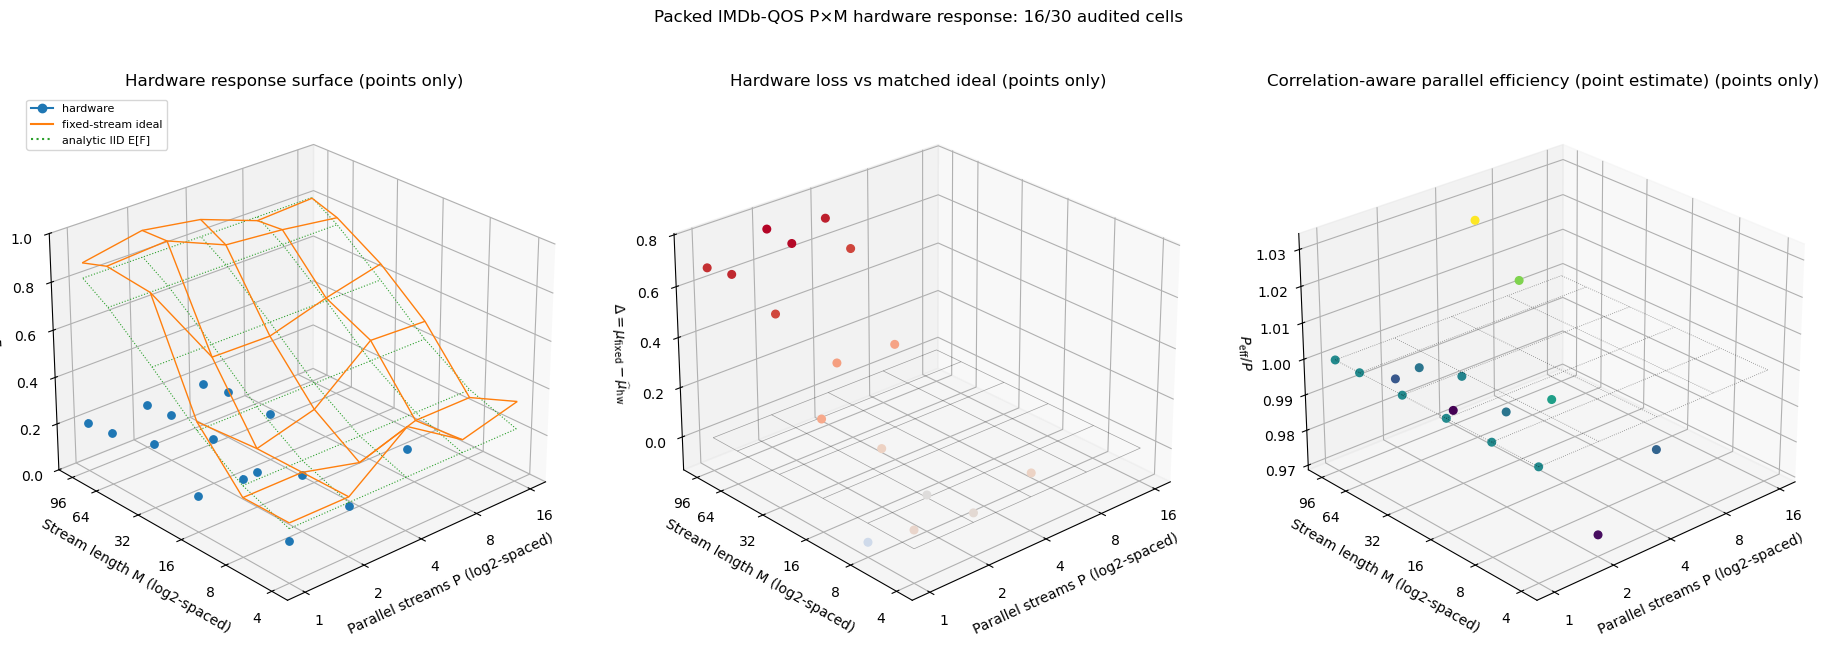

Saved: /Users/tangzhi/Desktop/Quafu/results/qos_parallel_ensemble/imdb_parallel_qos_grid_001_M_slices.png


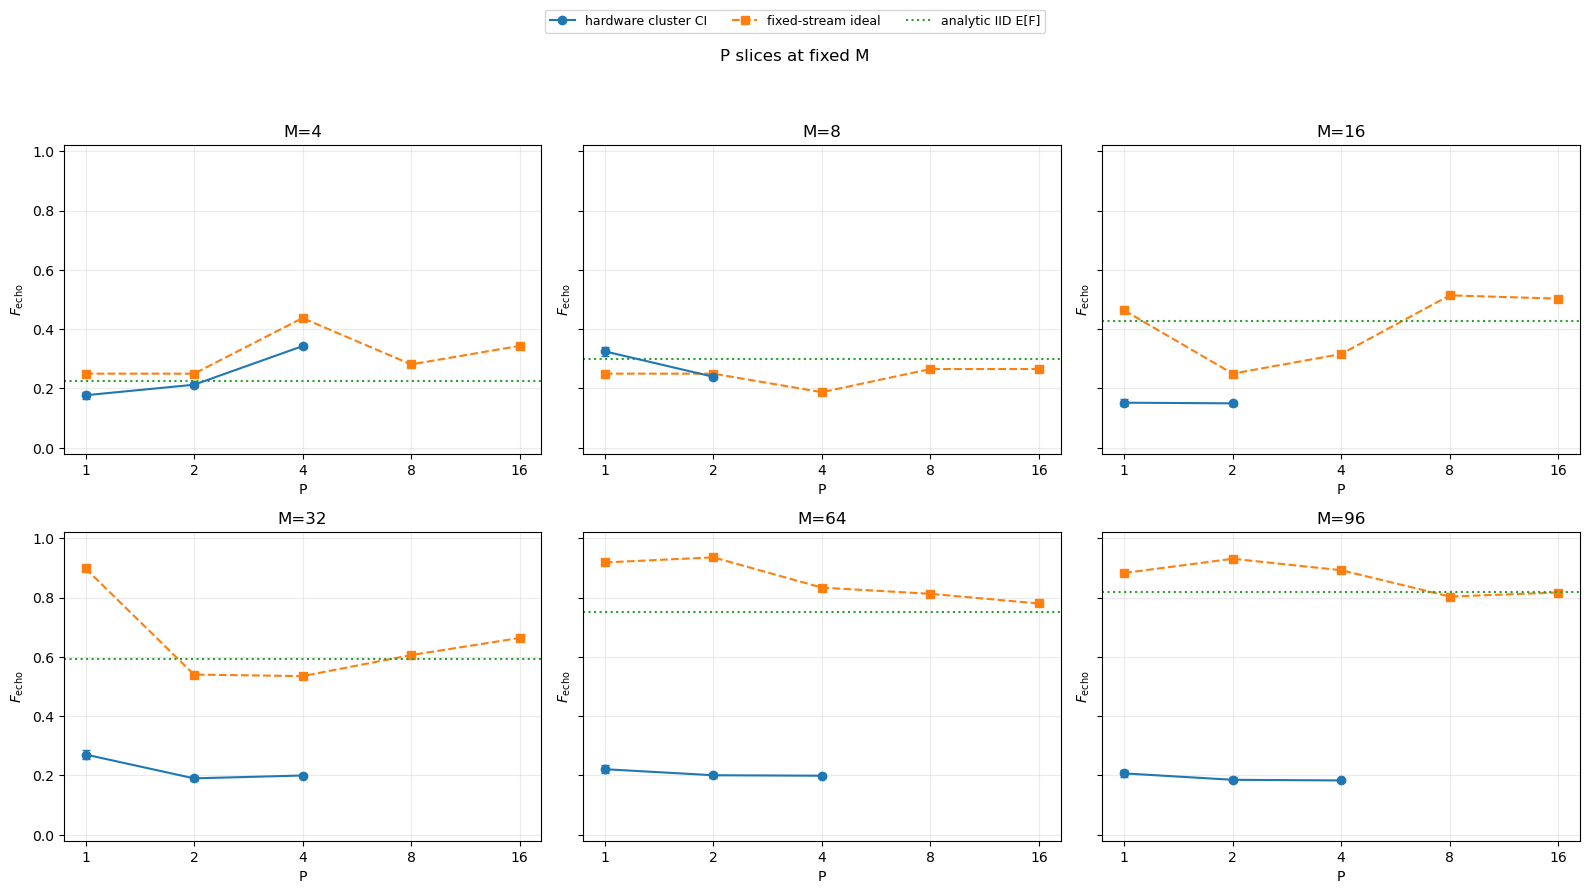

Saved: /Users/tangzhi/Desktop/Quafu/results/qos_parallel_ensemble/imdb_parallel_qos_grid_001_P_slices.png


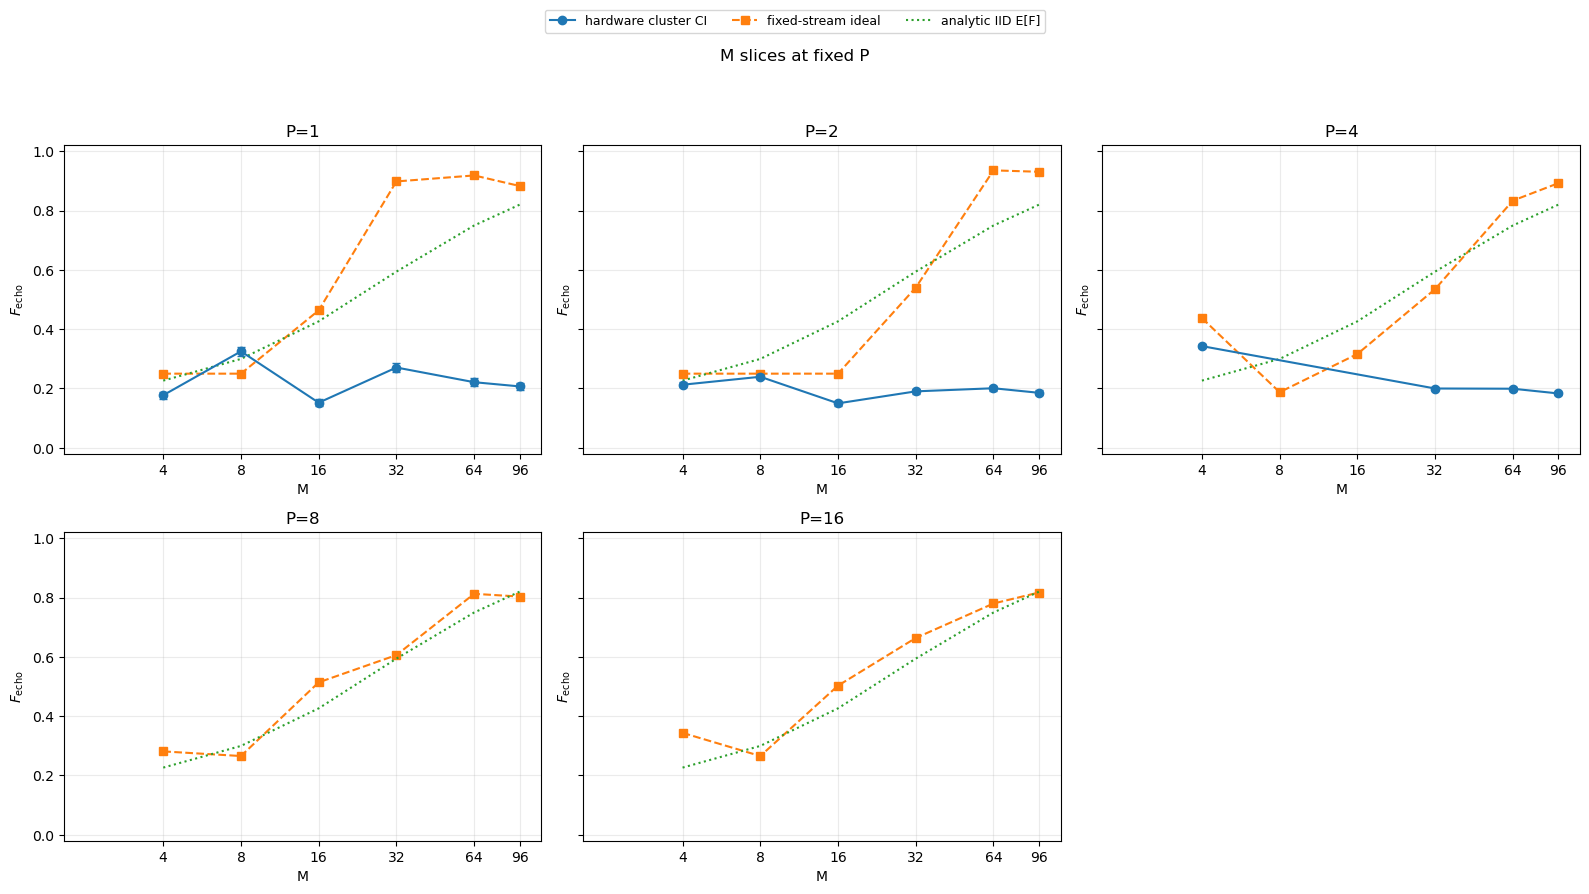

Saved: /Users/tangzhi/Desktop/Quafu/results/qos_parallel_ensemble/imdb_parallel_qos_grid_001_diagnostics_heatmaps.png


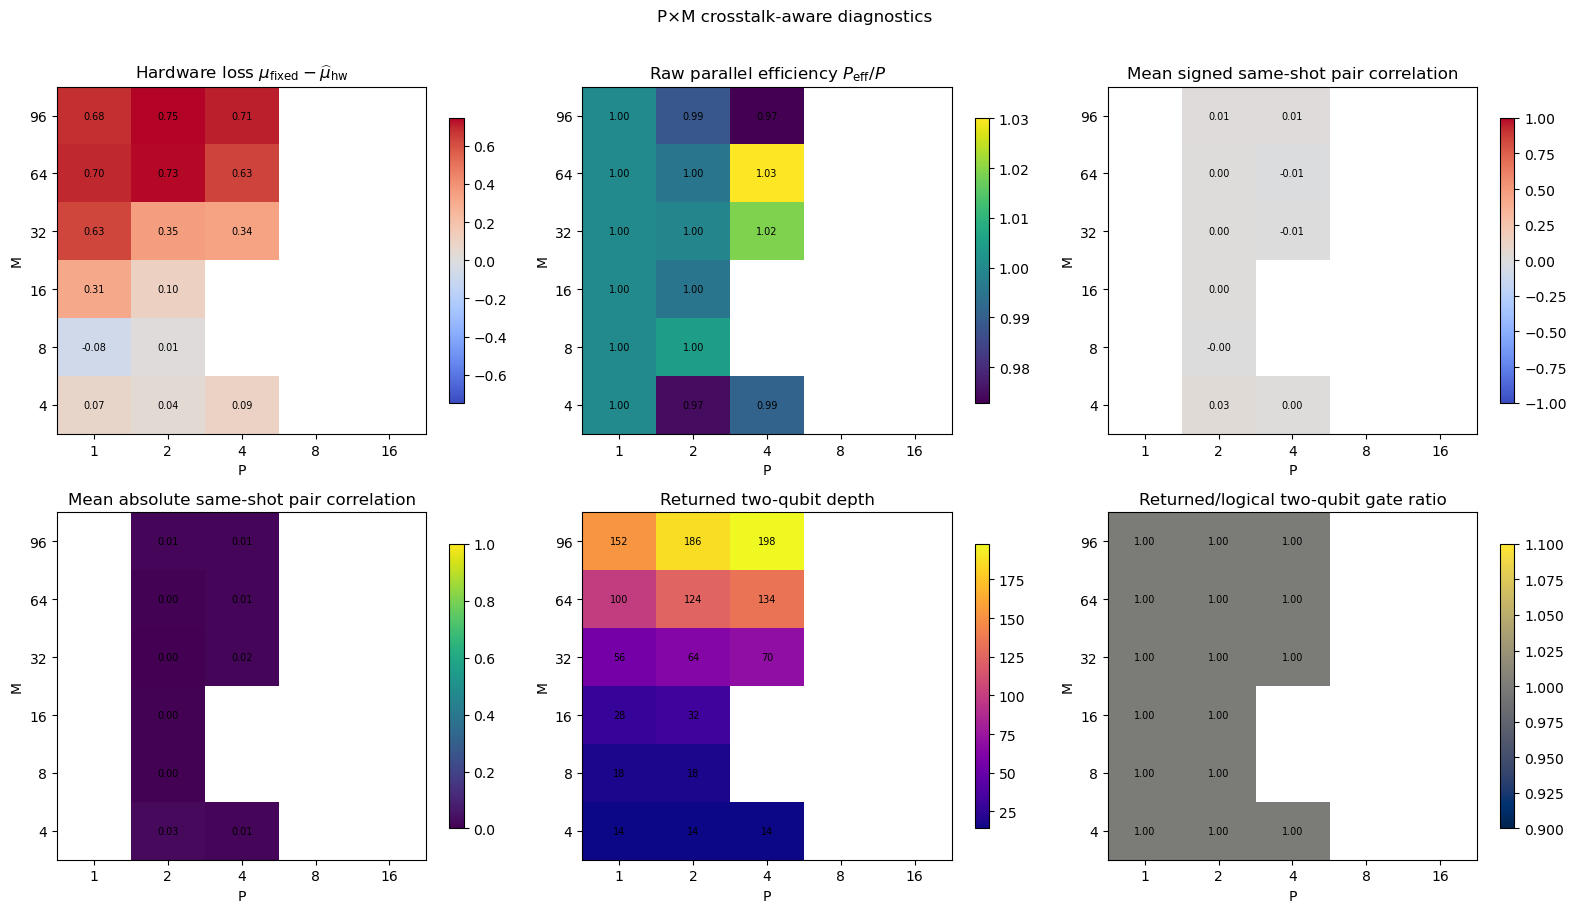

,P=1,P=2,P=4,P=8,P=16
M=4,ok,ok,ok,missing,missing
M=8,ok,ok,missing,missing,missing
M=16,ok,ok,missing,missing,missing
M=32,ok,ok,ok,missing,missing
M=64,ok,ok,ok,missing,missing
M=96,ok,ok,ok,missing,missing


,P_parallel_streams,M_data_per_stream,task_id,ensemble_raw_F_echo,ensemble_cluster_ci_low,ensemble_cluster_ci_high,ideal_ensemble_mean,hardware_loss_vs_fixed_ideal,mean_signed_offdiag_pair_corr,mean_abs_offdiag_pair_corr,effective_parallelism_raw,parallel_efficiency_raw,returned_two_qubit_gates,returned_two_qubit_depth,returned_layout_signature,layout_audit_pass
0,1,4,2607310810373622492,0.177246,0.165550,0.188942,0.250000,0.072754,NaN,NaN,1.000000,1.000000,14.0,14.0,"[[34,40]]",True
1,1,8,2607310810377523666,0.325195,0.310848,0.339543,0.250000,-0.075195,NaN,NaN,1.000000,1.000000,18.0,18.0,"[[34,40]]",True
2,1,16,2607310810381424102,0.152100,0.141100,0.163099,0.463388,0.311289,NaN,NaN,1.000000,1.000000,28.0,28.0,"[[34,40]]",True
3,1,32,2607310810385348008,0.270752,0.257142,0.284362,0.898232,0.627480,NaN,NaN,1.000000,1.000000,56.0,56.0,"[[34,40]]",True
4,1,64,2607310810389410769,0.221191,0.208479,0.233904,0.918488,0.697297,NaN,NaN,1.000000,1.000000,100.0,100.0,"[[34,40]]",True
5,1,96,2607310810394988671,0.207031,0.194621,0.219441,0.882893,0.675862,NaN,NaN,1.000000,1.000000,152.0,152.0,"[[34,40]]",True
6,2,4,2607310821430180214,0.212646,0.203671,0.221622,0.250000,0.037354,0.025988,0.025988,1.949344,0.974672,28.0,14.0,"[[41,48],[40,34]]",True
7,2,8,2607310821434299257,0.239502,0.230428,0.248576,0.250000,0.010498,-0.004955,0.004955,2.009705,1.004853,36.0,18.0,"[[40,34],[48,41]]",True
14,2,16,2607310919042542704,0.149902,0.142171,0.157633,0.250000,0.100098,0.004859,0.004859,1.990420,0.995210,56.0,32.0,"[[48,41],[34,40]]",True
9,2,32,2607310821442690814,0.190308,0.181802,0.198814,0.540291,0.349983,0.001186,0.001186,1.997632,0.998816,106.0,64.0,"[[41,48],[40,34]]",True


,P,completed_M,unique_layout_signatures,layout_consistent_across_M
0,1,"[4, 8, 16, 32, 64, 96]",1,True
1,2,"[4, 8, 16, 32, 64, 96]",4,False
2,4,"[4, 32, 64, 96]",3,False


In [185]:
task_frame = pd.DataFrame(
    read_json_list(TASK_RESULTS_JSON)
)
pair_frame = pd.DataFrame(
    read_json_list(PAIR_RESULTS_JSON)
)

required_task_columns = {
    "schema_version",
    "design_id",
    "campaign_label",
    "fetch_reason",
    "analysis_eligible",
    "layout_audit_pass",
    "P_parallel_streams",
    "M_data_per_stream",
    "base_stream_seed",
    "replicate_id",
    "assignment_id",
    "backend",
    "compiler",
    "correct",
    "open_dd",
    "target_qubits_requested",
    "shots_requested",
    "task_id",
}
completed = pd.DataFrame()
if (
    not task_frame.empty
    and required_task_columns.issubset(
        task_frame.columns
    )
):
    completed = task_frame.loc[
        (
            pd.to_numeric(
                task_frame["schema_version"],
                errors="coerce",
            )
            == SCHEMA_VERSION
        )
        & (task_frame["design_id"] == DESIGN_ID)
        & (
            task_frame["campaign_label"]
            == CAMPAIGN_LABEL
        )
        & (task_frame["fetch_reason"] == "ok")
        & task_frame["analysis_eligible"].astype(bool)
        & task_frame["layout_audit_pass"].astype(bool)
        & (
            pd.to_numeric(
                task_frame["P_parallel_streams"],
                errors="coerce",
            ).isin(P_VALUES)
        )
        & (
            pd.to_numeric(
                task_frame["M_data_per_stream"],
                errors="coerce",
            ).isin(M_VALUES)
        )
        & (
            pd.to_numeric(
                task_frame["base_stream_seed"],
                errors="coerce",
            )
            == BASE_STREAM_SEED
        )
        & (
            pd.to_numeric(
                task_frame["replicate_id"],
                errors="coerce",
            )
            == REPLICATE_ID
        )
        & (
            task_frame["assignment_id"]
            == ASSIGNMENT_ID
        )
        & (task_frame["backend"] == BACKEND)
        & (task_frame["compiler"] == COMPILER)
        & (
            task_frame["correct"].astype(bool)
            == bool(USE_READOUT_CORRECTION)
        )
        & (
            task_frame["open_dd"].map(
                lambda value: (
                    "__NONE__"
                    if value is None
                    or (
                        isinstance(value, float)
                        and np.isnan(value)
                    )
                    else str(value)
                )
            )
            == (
                "__NONE__"
                if OPEN_DD is None
                else str(OPEN_DD)
            )
        )
        & (
            pd.to_numeric(
                task_frame["shots_requested"],
                errors="coerce",
            )
            == SHOTS
        )
    ].copy()

    if not completed.empty:
        target_match = completed.apply(
            lambda row: tuple(
                int(item)
                for item in (
                    row["target_qubits_requested"]
                    if isinstance(
                        row[
                            "target_qubits_requested"
                        ],
                        list,
                    )
                    else []
                )
            )
            == tuple(
                int(item)
                for item in TARGET_QUBITS_BY_P.get(
                    int(row["P_parallel_streams"]),
                    [],
                )
            ),
            axis=1,
        )
        completed = completed.loc[
            target_match
        ].copy()

if not completed.empty:
    completed["P_parallel_streams"] = pd.to_numeric(
        completed["P_parallel_streams"]
    ).astype(int)
    completed["M_data_per_stream"] = pd.to_numeric(
        completed["M_data_per_stream"]
    ).astype(int)
    duplicate_cells = completed.duplicated(
        [
            "P_parallel_streams",
            "M_data_per_stream",
        ],
        keep=False,
    )
    if duplicate_cells.any():
        duplicate_view = completed.loc[
            duplicate_cells,
            [
                "P_parallel_streams",
                "M_data_per_stream",
                "task_id",
            ],
        ]
        raise RuntimeError(
            "Multiple successful tasks exist for a grid "
            "cell; choose an attempt explicitly before "
            "plotting:\n"
            + duplicate_view.to_string(index=False)
        )
    completed = completed.sort_values(
        ["P_parallel_streams", "M_data_per_stream"]
    )

completed_pairs = pd.DataFrame()
if (
    not pair_frame.empty
    and not completed.empty
    and "task_id" in pair_frame.columns
):
    completed_pairs = pair_frame.loc[
        pair_frame["task_id"].isin(
            completed["task_id"].tolist()
        )
    ].copy()

# Build the complete fixed-stream ideal grid without using
# hardware results. P and M both use the same nested prefixes.
ideal_rows = []
k_negative = int(np.sum(BOOLEAN_F))
for p_value in P_VALUES:
    full_streams = [
        full_stream_for_replica(replica_index)
        for replica_index in range(p_value)
    ]
    for m_data in M_VALUES:
        streams = [
            stream[:m_data].copy()
            for stream in full_streams
        ]
        ideal_values = [
            fixed_stream_metrics(stream)[
                "ideal_F_echo_fixed"
            ]
            for stream in streams
        ]
        logical_2q_gates = 2 * sum(
            int(np.sum(BOOLEAN_F[stream]))
            + k_negative
            for stream in streams
        )
        active_sample_steps = sum(
            any(
                int(BOOLEAN_F[stream[t]]) == 1
                for stream in streams
            )
            for t in range(m_data)
        )
        logical_2q_depth = 2 * (
            active_sample_steps + k_negative
        )
        ideal_rows.append(
            {
                "P_parallel_streams": p_value,
                "M_data_per_stream": m_data,
                "ideal_ensemble_mean": float(
                    np.mean(ideal_values)
                ),
                "ideal_values": ideal_values,
                "analytic_E_iid_F_echo": (
                    expected_iid_F_echo(m_data)
                ),
                "logical_two_qubit_gates": (
                    logical_2q_gates
                ),
                "logical_two_qubit_depth": (
                    logical_2q_depth
                ),
            }
        )
ideal_grid = pd.DataFrame(ideal_rows)

# Validate resource formulas against the six Qiskit audits
# generated for the currently selected P.
for m_data in M_VALUES:
    ideal_row = ideal_grid.loc[
        (
            ideal_grid["P_parallel_streams"]
            == P_SELECTED
        )
        & (
            ideal_grid["M_data_per_stream"]
            == m_data
        )
    ].iloc[0]
    manifest = experiment_bundles[m_data]["manifest"]
    if (
        int(ideal_row["logical_two_qubit_gates"])
        != int(manifest["logical_two_qubit_gates"])
        or int(ideal_row["logical_two_qubit_depth"])
        != int(manifest["logical_two_qubit_depth"])
    ):
        raise AssertionError(
            f"Resource formula mismatch for M={m_data}."
        )

p_positions = np.arange(
    len(P_VALUES), dtype=float
)
m_positions = np.log2(
    np.asarray(M_VALUES, dtype=float)
)
X, Y = np.meshgrid(p_positions, m_positions)


def grid_from_frame(frame, value_column):
    output = np.full(
        (len(M_VALUES), len(P_VALUES)),
        np.nan,
        dtype=float,
    )
    if frame.empty or value_column not in frame.columns:
        return output
    for row in frame.itertuples(index=False):
        p_value = int(
            getattr(row, "P_parallel_streams")
        )
        m_data = int(
            getattr(row, "M_data_per_stream")
        )
        if p_value in P_VALUES and m_data in M_VALUES:
            output[
                M_VALUES.index(m_data),
                P_VALUES.index(p_value),
            ] = float(getattr(row, value_column))
    return output


ideal_z = grid_from_frame(
    ideal_grid, "ideal_ensemble_mean"
)
iid_z = grid_from_frame(
    ideal_grid, "analytic_E_iid_F_echo"
)
hardware_z = grid_from_frame(
    completed, "ensemble_raw_F_echo"
)
hardware_loss_z = ideal_z - hardware_z
finite_loss_values = hardware_loss_z[
    np.isfinite(hardware_loss_z)
]
loss_color_limit = (
    float(
        max(
            1e-6,
            np.max(np.abs(finite_loss_values)),
        )
    )
    if finite_loss_values.size
    else 1.0
)
efficiency_z = grid_from_frame(
    completed, "parallel_efficiency_raw"
)
signed_corr_z = grid_from_frame(
    completed, "mean_signed_offdiag_pair_corr"
)
abs_corr_z = grid_from_frame(
    completed, "mean_abs_offdiag_pair_corr"
)
returned_depth_z = grid_from_frame(
    completed, "returned_two_qubit_depth"
)
returned_gates_z = grid_from_frame(
    completed, "returned_two_qubit_gates"
)
logical_gates_z = grid_from_frame(
    ideal_grid, "logical_two_qubit_gates"
)
gate_inflation_z = np.divide(
    returned_gates_z,
    logical_gates_z,
    out=np.full_like(returned_gates_z, np.nan),
    where=logical_gates_z > 0,
)

completed_cells = int(np.isfinite(hardware_z).sum())
total_cells = len(P_VALUES) * len(M_VALUES)
grid_complete = completed_cells == total_cells
print(
    f"Strict audited grid completion: "
    f"{completed_cells}/{total_cells}"
)


def format_3d_axes(axis, z_label):
    axis.set_xticks(p_positions)
    axis.set_xticklabels([str(p) for p in P_VALUES])
    axis.set_yticks(m_positions)
    axis.set_yticklabels([str(m) for m in M_VALUES])
    axis.set_xlabel("Parallel streams P (log2-spaced)")
    axis.set_ylabel("Stream length M (log2-spaced)")
    axis.set_zlabel(z_label)
    axis.view_init(elev=26, azim=-132)


fig_3d = plt.figure(figsize=(19, 6.5))

axis = fig_3d.add_subplot(1, 3, 1, projection="3d")
axis.plot_wireframe(
    X,
    Y,
    ideal_z,
    color="tab:orange",
    linewidth=1.0,
    label="fixed-stream ideal",
)
axis.plot_wireframe(
    X,
    Y,
    iid_z,
    color="tab:green",
    linewidth=0.8,
    linestyle=":",
    label="analytic IID E[F]",
)
finite = np.isfinite(hardware_z)
if grid_complete:
    axis.plot_surface(
        X,
        Y,
        hardware_z,
        cmap="Blues",
        alpha=0.72,
        linewidth=0,
        antialiased=True,
    )
if finite.any():
    axis.scatter(
        X[finite],
        Y[finite],
        hardware_z[finite],
        color="tab:blue",
        s=28,
        depthshade=False,
        label="hardware",
    )
    if not completed.empty:
        for row in completed.itertuples(index=False):
            x_value = float(
                P_VALUES.index(
                    int(row.P_parallel_streams)
                )
            )
            y_value = float(
                np.log2(row.M_data_per_stream)
            )
            low = float(
                row.ensemble_cluster_ci_low
            )
            high = float(
                row.ensemble_cluster_ci_high
            )
            axis.plot(
                [x_value, x_value],
                [y_value, y_value],
                [low, high],
                color="tab:blue",
                linewidth=1.0,
            )
axis.set_zlim(0.0, 1.0)
axis.set_title(
    "Hardware response surface"
    + ("" if grid_complete else " (points only)")
)
format_3d_axes(axis, r"$F_{\rm echo}$")
axis.legend(
    handles=[
        Line2D(
            [0], [0], color="tab:blue",
            marker="o", label="hardware"
        ),
        Line2D(
            [0], [0], color="tab:orange",
            label="fixed-stream ideal"
        ),
        Line2D(
            [0], [0], color="tab:green",
            linestyle=":", label="analytic IID E[F]"
        ),
    ],
    fontsize=8,
    loc="upper left",
)

axis = fig_3d.add_subplot(1, 3, 2, projection="3d")
finite = np.isfinite(hardware_loss_z)
if grid_complete:
    axis.plot_surface(
        X,
        Y,
        hardware_loss_z,
        cmap="coolwarm",
        vmin=-loss_color_limit,
        vmax=loss_color_limit,
        alpha=0.78,
        linewidth=0,
    )
if finite.any():
    axis.scatter(
        X[finite],
        Y[finite],
        hardware_loss_z[finite],
        c=hardware_loss_z[finite],
        cmap="coolwarm",
        vmin=-loss_color_limit,
        vmax=loss_color_limit,
        s=30,
        depthshade=False,
    )
axis.plot_wireframe(
    X,
    Y,
    np.zeros_like(X),
    color="black",
    linewidth=0.5,
    alpha=0.35,
)
axis.set_title(
    "Hardware loss vs matched ideal"
    + ("" if grid_complete else " (points only)")
)
format_3d_axes(
    axis,
    r"$\Delta=\mu_{\rm fixed}-\widehat\mu_{\rm hw}$",
)

axis = fig_3d.add_subplot(1, 3, 3, projection="3d")
finite = np.isfinite(efficiency_z)
if grid_complete:
    axis.plot_surface(
        X,
        Y,
        efficiency_z,
        cmap="viridis",
        alpha=0.78,
        linewidth=0,
    )
if finite.any():
    axis.scatter(
        X[finite],
        Y[finite],
        efficiency_z[finite],
        c=efficiency_z[finite],
        cmap="viridis",
        s=30,
        depthshade=False,
    )
axis.plot_wireframe(
    X,
    Y,
    np.ones_like(X),
    color="black",
    linewidth=0.6,
    linestyle=":",
    alpha=0.45,
)
axis.set_title(
    "Correlation-aware parallel efficiency (point estimate)"
    + ("" if grid_complete else " (points only)")
)
format_3d_axes(axis, r"$P_{\rm eff}/P$")

fig_3d.suptitle(
    (
        "Packed IMDb-QOS P×M hardware response: "
        f"{completed_cells}/{total_cells} audited cells"
    ),
    y=1.01,
)
fig_3d.subplots_adjust(
    left=0.01,
    right=0.99,
    bottom=0.04,
    top=0.88,
    wspace=0.02,
)
surface_path = (
    RESULT_ROOT
    / f"{CAMPAIGN_LABEL}_response_surface_3d.png"
)
fig_3d.savefig(
    surface_path, dpi=190, bbox_inches="tight"
)
print("Saved:", surface_path)
plt.show()

# Precise 2D slices: one panel per M.
fig_slices, axes = plt.subplots(
    2, 3, figsize=(16, 9), sharex=True, sharey=True
)
for axis, m_data in zip(axes.flat, M_VALUES):
    ideal_slice = ideal_grid.loc[
        ideal_grid["M_data_per_stream"] == m_data
    ].sort_values("P_parallel_streams")
    axis.plot(
        ideal_slice["P_parallel_streams"],
        ideal_slice["ideal_ensemble_mean"],
        "s--",
        color="tab:orange",
        label="fixed-stream ideal",
    )
    axis.axhline(
        expected_iid_F_echo(m_data),
        color="tab:green",
        linestyle=":",
        label="analytic IID E[F]",
    )
    if not completed.empty:
        hardware_slice = completed.loc[
            completed["M_data_per_stream"] == m_data
        ].sort_values("P_parallel_streams")
        if not hardware_slice.empty:
            x = hardware_slice[
                "P_parallel_streams"
            ].to_numpy(dtype=float)
            y = pd.to_numeric(
                hardware_slice[
                    "ensemble_raw_F_echo"
                ]
            ).to_numpy(dtype=float)
            low = pd.to_numeric(
                hardware_slice[
                    "ensemble_cluster_ci_low"
                ]
            ).to_numpy(dtype=float)
            high = pd.to_numeric(
                hardware_slice[
                    "ensemble_cluster_ci_high"
                ]
            ).to_numpy(dtype=float)
            axis.errorbar(
                x,
                y,
                yerr=np.vstack([y - low, high - y]),
                fmt="o-",
                capsize=3,
                label="hardware cluster CI",
            )
    axis.set_title(f"M={m_data}")
    axis.set_xscale("log", base=2)
    axis.set_xticks(P_VALUES)
    axis.set_xticklabels([str(p) for p in P_VALUES])
    axis.tick_params(axis="x", labelbottom=True)
    axis.set_ylim(-0.02, 1.02)
    axis.grid(alpha=0.25)
    axis.set_xlabel("P")
    axis.set_ylabel(r"$F_{\rm echo}$")
handles, labels = axes.flat[0].get_legend_handles_labels()
if not completed.empty:
    handles = [
        Line2D(
            [0], [0], color="tab:blue",
            marker="o", label="hardware cluster CI"
        ),
        Line2D(
            [0], [0], color="tab:orange",
            marker="s", linestyle="--",
            label="fixed-stream ideal"
        ),
        Line2D(
            [0], [0], color="tab:green",
            linestyle=":", label="analytic IID E[F]"
        ),
    ]
    labels = [item.get_label() for item in handles]
fig_slices.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=3,
    fontsize=9,
)
fig_slices.suptitle(
    "P slices at fixed M", y=0.945
)
fig_slices.tight_layout(
    rect=[0.0, 0.0, 1.0, 0.91]
)
slices_path = (
    RESULT_ROOT
    / f"{CAMPAIGN_LABEL}_M_slices.png"
)
fig_slices.savefig(
    slices_path, dpi=180, bbox_inches="tight"
)
print("Saved:", slices_path)
plt.show()

# Complementary M-direction slices: one panel per P.
fig_p_slices, axes = plt.subplots(
    2, 3, figsize=(16, 9), sharex=True, sharey=True
)
for axis, p_value in zip(
    axes.flat, P_VALUES
):
    ideal_slice = ideal_grid.loc[
        ideal_grid["P_parallel_streams"] == p_value
    ].sort_values("M_data_per_stream")
    axis.plot(
        ideal_slice["M_data_per_stream"],
        ideal_slice["ideal_ensemble_mean"],
        "s--",
        color="tab:orange",
        label="fixed-stream ideal",
    )
    axis.plot(
        ideal_slice["M_data_per_stream"],
        ideal_slice["analytic_E_iid_F_echo"],
        ":",
        color="tab:green",
        label="analytic IID E[F]",
    )
    if not completed.empty:
        hardware_slice = completed.loc[
            completed["P_parallel_streams"]
            == p_value
        ].sort_values("M_data_per_stream")
        if not hardware_slice.empty:
            x = hardware_slice[
                "M_data_per_stream"
            ].to_numpy(dtype=float)
            y = pd.to_numeric(
                hardware_slice[
                    "ensemble_raw_F_echo"
                ]
            ).to_numpy(dtype=float)
            low = pd.to_numeric(
                hardware_slice[
                    "ensemble_cluster_ci_low"
                ]
            ).to_numpy(dtype=float)
            high = pd.to_numeric(
                hardware_slice[
                    "ensemble_cluster_ci_high"
                ]
            ).to_numpy(dtype=float)
            axis.errorbar(
                x,
                y,
                yerr=np.vstack([y - low, high - y]),
                fmt="o-",
                capsize=3,
                label="hardware cluster CI",
            )
    axis.set_title(f"P={p_value}")
    axis.set_xscale("log", base=2)
    axis.set_xticks(M_VALUES)
    axis.set_xticklabels(
        [str(m) for m in M_VALUES]
    )
    axis.tick_params(axis="x", labelbottom=True)
    axis.set_ylim(-0.02, 1.02)
    axis.grid(alpha=0.25)
    axis.set_xlabel("M")
    axis.set_ylabel(r"$F_{\rm echo}$")
axes.flat[-1].axis("off")
p_slice_handles = [
    Line2D(
        [0], [0], color="tab:blue",
        marker="o", label="hardware cluster CI"
    ),
    Line2D(
        [0], [0], color="tab:orange",
        marker="s", linestyle="--",
        label="fixed-stream ideal"
    ),
    Line2D(
        [0], [0], color="tab:green",
        linestyle=":", label="analytic IID E[F]"
    ),
]
fig_p_slices.legend(
    p_slice_handles,
    [item.get_label() for item in p_slice_handles],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=3,
    fontsize=9,
)
fig_p_slices.suptitle(
    "M slices at fixed P", y=0.945
)
fig_p_slices.tight_layout(
    rect=[0.0, 0.0, 1.0, 0.91]
)
p_slices_path = (
    RESULT_ROOT
    / f"{CAMPAIGN_LABEL}_P_slices.png"
)
fig_p_slices.savefig(
    p_slices_path, dpi=180, bbox_inches="tight"
)
print("Saved:", p_slices_path)
plt.show()


def draw_heatmap(
    axis,
    values,
    title,
    cmap,
    value_format=".2f",
    vmin=None,
    vmax=None,
):
    masked = np.ma.masked_invalid(values)
    image = axis.imshow(
        masked,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    axis.set_xticks(range(len(P_VALUES)))
    axis.set_xticklabels([str(p) for p in P_VALUES])
    axis.set_yticks(range(len(M_VALUES)))
    axis.set_yticklabels([str(m) for m in M_VALUES])
    axis.set_xlabel("P")
    axis.set_ylabel("M")
    axis.set_title(title)
    for m_index in range(len(M_VALUES)):
        for p_index in range(len(P_VALUES)):
            value = values[m_index, p_index]
            if np.isfinite(value):
                axis.text(
                    p_index,
                    m_index,
                    format(value, value_format),
                    ha="center",
                    va="center",
                    fontsize=7,
                )
    plt.colorbar(image, ax=axis, shrink=0.82)


fig_diag, axes = plt.subplots(
    2, 3, figsize=(16, 9)
)
draw_heatmap(
    axes[0, 0],
    hardware_loss_z,
    r"Hardware loss $\mu_{\rm fixed}-\widehat\mu_{\rm hw}$",
    "coolwarm",
    vmin=-loss_color_limit,
    vmax=loss_color_limit,
)
draw_heatmap(
    axes[0, 1],
    efficiency_z,
    r"Raw parallel efficiency $P_{\rm eff}/P$",
    "viridis",
)
draw_heatmap(
    axes[0, 2],
    signed_corr_z,
    "Mean signed same-shot pair correlation",
    "coolwarm",
    vmin=-1,
    vmax=1,
)
draw_heatmap(
    axes[1, 0],
    abs_corr_z,
    "Mean absolute same-shot pair correlation",
    "viridis",
    vmin=0,
    vmax=1,
)
draw_heatmap(
    axes[1, 1],
    returned_depth_z,
    "Returned two-qubit depth",
    "plasma",
    value_format=".0f",
)
draw_heatmap(
    axes[1, 2],
    gate_inflation_z,
    "Returned/logical two-qubit gate ratio",
    "cividis",
)
fig_diag.suptitle(
    "P×M crosstalk-aware diagnostics", y=1.01
)
fig_diag.tight_layout()
diagnostics_path = (
    RESULT_ROOT
    / f"{CAMPAIGN_LABEL}_diagnostics_heatmaps.png"
)
fig_diag.savefig(
    diagnostics_path, dpi=180, bbox_inches="tight"
)
print("Saved:", diagnostics_path)
plt.show()

grid_completion = pd.DataFrame(
    np.where(np.isfinite(hardware_z), "ok", "missing"),
    index=[f"M={m}" for m in M_VALUES],
    columns=[f"P={p}" for p in P_VALUES],
)
display(grid_completion)

if not completed.empty:
    display(
        completed[
            [
                "P_parallel_streams",
                "M_data_per_stream",
                "task_id",
                "ensemble_raw_F_echo",
                "ensemble_cluster_ci_low",
                "ensemble_cluster_ci_high",
                "ideal_ensemble_mean",
                "hardware_loss_vs_fixed_ideal",
                "mean_signed_offdiag_pair_corr",
                "mean_abs_offdiag_pair_corr",
                "effective_parallelism_raw",
                "parallel_efficiency_raw",
                "returned_two_qubit_gates",
                "returned_two_qubit_depth",
                "returned_layout_signature",
                "layout_audit_pass",
            ]
        ]
    )
else:
    print(
        "No strictly audited hardware result in this "
        "P×M campaign yet."
    )

layout_consistency_rows = []
if not completed.empty:
    for p_value, group in completed.groupby(
        "P_parallel_streams"
    ):
        signatures = group[
            "returned_layout_signature"
        ].dropna()
        layout_consistency_rows.append(
            {
                "P": int(p_value),
                "completed_M": sorted(
                    group[
                        "M_data_per_stream"
                    ].astype(int)
                ),
                "unique_layout_signatures": int(
                    signatures.nunique()
                ),
                "layout_consistent_across_M": bool(
                    len(group) == len(M_VALUES)
                    and signatures.nunique() == 1
                ),
            }
        )
if layout_consistency_rows:
    display(pd.DataFrame(layout_consistency_rows))


## 8. 初步二维“串扰感知”趋势模型

当有足够多的 $(P,M)$ 网格点时，notebook 拟合描述性模型：

$$
\Delta(P,M)
=
\mu_{\rm fixed}-\widehat\mu_{\rm hw}
=
\beta_0
+\beta_P\log_2P
+\beta_M\log_2M
+\beta_{PM}\log_2P\log_2M
+\varepsilon.
$$

正系数表示硬件损失增大。$\beta_{PM}$ 描述“并行宽度增加时，
线路加深的综合退化是否改变”。
但每个网格只有一个 task；$P$、$M$ 还与运行时间、自动布局、
physical-pair quality 和编译结果混杂，所以这些系数不是因果
串扰估计。shot-level cluster CI 也不包含跨任务或跨日漂移。


In [186]:
trend_summary = {
    "schema_version": SCHEMA_VERSION,
    "design_id": DESIGN_ID,
    "campaign_label": CAMPAIGN_LABEL,
    "P_values": list(P_VALUES),
    "M_values": list(M_VALUES),
    "base_stream_seed": BASE_STREAM_SEED,
    "replicate_id": REPLICATE_ID,
    "assignment_id": ASSIGNMENT_ID,
    "n_completed_cells": int(len(completed)),
    "grid_cells_expected": int(
        len(P_VALUES) * len(M_VALUES)
    ),
    "grid_complete": bool(
        len(completed)
        == len(P_VALUES) * len(M_VALUES)
    ),
    "model": (
        "fixed_ideal_minus_hardware ~ 1 + log2(P) "
        "+ log2(M) + log2(P):log2(M)"
    ),
    "causal_crosstalk_claim_allowed": False,
}

enough_cells = bool(
    len(completed)
    == len(P_VALUES) * len(M_VALUES)
)
if enough_cells:
    log_p = np.log2(
        completed[
            "P_parallel_streams"
        ].to_numpy(dtype=float)
    )
    log_m = np.log2(
        completed[
            "M_data_per_stream"
        ].to_numpy(dtype=float)
    )
    response = (
        pd.to_numeric(
            completed["ideal_ensemble_mean"]
        ).to_numpy(dtype=float)
        - pd.to_numeric(
            completed["ensemble_raw_F_echo"]
        ).to_numpy(dtype=float)
    )
    design = np.column_stack(
        [
            np.ones_like(log_p),
            log_p,
            log_m,
            log_p * log_m,
        ]
    )
    coefficients, _, _, _ = np.linalg.lstsq(
        design, response, rcond=None
    )
    fitted = design @ coefficients
    residuals = response - fitted
    degrees_freedom = len(response) - design.shape[1]
    standard_errors = np.full(4, np.nan)
    if degrees_freedom > 0:
        residual_variance = float(
            residuals @ residuals / degrees_freedom
        )
        covariance = (
            residual_variance
            * np.linalg.pinv(design.T @ design)
        )
        standard_errors = np.sqrt(
            np.diag(covariance)
        )
    total_sum_squares = float(
        np.sum(
            (response - np.mean(response)) ** 2
        )
    )
    r_squared = (
        1
        - float(residuals @ residuals)
        / total_sum_squares
        if total_sum_squares > 0
        else np.nan
    )
    names = [
        "intercept",
        "log2_P",
        "log2_M",
        "log2_P_x_log2_M",
    ]
    trend_summary.update(
        {
            "coefficients": {
                name: float(value)
                for name, value in zip(
                    names, coefficients
                )
            },
            "naive_standard_errors": {
                name: float(value)
                for name, value in zip(
                    names, standard_errors
                )
            },
            "r_squared_descriptive": float(r_squared),
            "warning": (
                "Descriptive only: one task per cell; "
                "layout, time, compiler and physical-pair "
                "quality are not separated."
            ),
        }
    )
else:
    trend_summary["warning"] = (
        "The descriptive interaction model is withheld "
        "until the strictly audited grid is complete "
        "(30/30), avoiding an unbalanced partial-fetch fit."
    )

trend_path = (
    RESULT_ROOT
    / f"{CAMPAIGN_LABEL}_pm_trend.json"
)
write_json_atomic(trend_path, trend_summary)
display(
    pd.Series(trend_summary, name="trend").to_frame()
)
print("Saved:", trend_path)


,trend
schema_version,2
design_id,pm_grid_v1
campaign_label,imdb_parallel_qos_grid_001
P_values,"[1, 2, 4, 8, 16]"
M_values,"[4, 8, 16, 32, 64, 96]"
base_stream_seed,20260731
replicate_id,0
assignment_id,auto_v0
n_completed_cells,16
grid_cells_expected,30


Saved: /Users/tangzhi/Desktop/Quafu/results/qos_parallel_ensemble/imdb_parallel_qos_grid_001_pm_trend.json


## 9. 你实际需要怎样运行

### 第一轮：$P=1$，六个 $M$

1. 保持：

   ```python
   P_SELECTED = 1
   ACTION = "dry_run"
   CONFIRM_REAL_SUBMISSION = ""
   CONFIRM_BATCH_DIGEST = ""
   ```

   完整 `Run All`。它会离线生成并审计 $M=4,8,16,32,64,96$
   六条 QASM，同时打印 batch digest、12 位 digest 确认值和确认词。

2. 可选：改成 `ACTION="status"`，完整 `Run All` 查看后端和当前
   六个任务槽位。

3. 新批次提交时，按 dry-run 的输出填写：

   ```python
   ACTION = "submit"
   CONFIRM_REAL_SUBMISSION = "SUBMIT_6_TASKS_FOR_P_1"
   CONFIRM_BATCH_DIGEST = "把 dry_run 打印的 12 位值粘到这里"
   ```

   完整 `Run All`。这会顺序提交六个 task；每个 task ID 返回后
   立即写入 registry 和 receipt。

4. 提交后立即清空两个确认字符串。用 `ACTION="status"` 等到六个
   task 都完成。

5. 改成：

   ```python
   ACTION = "fetch"
   CONFIRM_REAL_SUBMISSION = ""
   CONFIRM_BATCH_DIGEST = ""
   ```

   完整 `Run All`。若六个任务都已完成，一次 fetch 就会全部取回。
   若仍有排队任务，已完成部分会先保存；等待后幂等地再运行 fetch，
   不会用 pending 状态覆盖成功结果。

### 后面四轮

依次把 `P_SELECTED` 改成：

```python
2
4
8
16
```

每个 $P$ 都重复“一次六任务 submit → 等待 → 一次批量 fetch”。
确认词中的 $P$ 也随之改变。全部完成后总计：

$$
5\ P\text{ 档}\times6\ M\text{ 档}=30\text{ 个 task ID}.
$$

### 部分提交恢复

如果某次 submit 在中间停止：

1. 先查看 `task_registry.json`、receipt 和 `submission_intents/`；
2. 如果 intent 标为 `submitting` 或 `ambiguous`，必须先在平台按
   `task_name` 核实，不要直接重试。平台确有任务时填
   `RECOVER_TASK_IDS_BY_M={M: task_id}`；确认平台未创建任务时填
   `AMBIGUOUS_M_VERIFIED_NOT_SUBMITTED=(M,)`；
3. 完成核实后设置：

   ```python
   RESUME_PARTIAL_BATCH = True
   CONFIRM_REAL_SUBMISSION = (
       "RESUME_MISSING_TASKS_FOR_P_当前P"
   )
   CONFIRM_BATCH_DIGEST = "同一批次的 12 位值"
   ACTION = "submit"
   ```

   notebook 只会补交没有有效 task ID 的网格点。

### 已有 task ID 的失败或审计失败重试

不要删除旧 registry 记录。先用 `ACTION="fetch"` 保存失败状态或
returned-layout 审计结果。然后设置，例如当前 $P=2$ 的
$M=16,96$：

```python
P_SELECTED = 2
RETRY_M_VALUES = (16, 96)
ACTION = "dry_run"
CONFIRM_REAL_SUBMISSION = ""
CONFIRM_BATCH_DIGEST = ""
```

dry-run 会打印专用确认词。核对后改成：

```python
ACTION = "retry"
CONFIRM_REAL_SUBMISSION = (
    "RETRY_FAILED_TASKS_FOR_P_2_M16_M96"
)
CONFIRM_BATCH_DIGEST = "P=2 原批次的 12 位值"
```

Notebook 会先实时验证旧 task 的终态和 `fetch_reason`；只有平台
终态失败或 `audit_failed` 才能替换。新 task ID 返回后，旧记录会
标为 superseded 但不会删除。随后清空 `RETRY_M_VALUES` 和确认字段，
等待新任务完成后用普通 `ACTION="fetch"` 取回。

### 重要科学边界

- $P=16,M=96$ 是 32-qubit 深线路压力测试，很可能接近噪声地板；
- 不要因为某个任务 queued 就重复 submit；
- 如果 returned-layout 审计失败，该点仍保存 raw 数据，但不进入
  三维主图；
- 同一 $P$ 的六个 $M$ 可能被编译到不同物理 pairs；notebook 会
  报告 layout 是否一致；
- $1-F_{\rm echo}$ 不是论文中的 operator error $\epsilon$；
- 30 个任务仍只有每格一个 task，足够画探索性响应面，不足以完成
  因果串扰或正式 mixed-effects 推断。
